In [123]:
import numpy as np
import matplotlib.pyplot as plt

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, Tuple
import numpy as np

In [124]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize, minimize_scalar
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# 3-period benchmark model without technology capital M
# Regimes: EXIT, D (domestic), X (exporter), HF (MNE)
#
# This file contains:
# 1. CES reduced-form profit definitions
# 2. A productivity Markov chain (Rouwenhorst)
# 3. A solver for the period-2 problem
# 4. A solver for the period-1 problem
# 5. A solver for the period-0 entrant problem with a signal q
# 6. Visualization helpers
#
# Main refactor:
# The set of analyzed regimes is configurable.
# Examples:
#   RegimeConfig(active_modes=("D", "X"))
#   RegimeConfig(active_modes=("EXIT", "D", "X"))
#   RegimeConfig(active_modes=("EXIT", "D", "X", "HF"))
# ------------------------------------------------------------

ALL_MODES = ("EXIT", "D", "X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = ALL_MODES

    def __post_init__(self) -> None:
        if len(self.active_modes) == 0:
            raise ValueError("active_modes cannot be empty.")
        if len(set(self.active_modes)) != len(self.active_modes):
            raise ValueError("active_modes contains duplicates.")
        invalid = [m for m in self.active_modes if m not in ALL_MODES]
        if invalid:
            raise ValueError(f"Invalid modes in active_modes: {invalid}")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}

    def contains(self, mode: str) -> bool:
        return mode in self.active_modes

    def home_active(self, mode: str) -> bool:
        return mode in ("D", "X", "HF")

    def foreign_active(self, mode: str) -> bool:
        return mode == "HF"


@dataclass
class ModelParams:
    # -------------------------
    # Dynamic parameters
    # -------------------------
    beta: float = 0.98
    delta: float = 0.10
    phi_H_adj: float = 2.0
    phi_F_adj: float = 2.0
    xi_H: float = 0.40   # terminal liquidation value for KH
    xi_F: float = 0.40   # terminal liquidation value for KF

    # -------------------------
    # CES / technology parameters
    # No technology capital benchmark: varphi = 0
    # -------------------------
    sigma: float = 5.0
    alpha: float = 0.30
    A_H: float = 1.5
    A_F: float = 1.5
    Lambda_H: float = 1.00
    Lambda_F: float = 1.20
    w_H: float = 1.00
    w_F: float = 1.00
    tau_X: float = 1.1

    # -------------------------
    # Operating costs
    # -------------------------
    f_H_op: float = 0.1
    f_X_op: float = 0.05
    f_F_op: float = 0.1

    # -------------------------
    # One-time regime/entry costs
    # -------------------------
    f_H_E: float = 0.2
    f_X_E: float = 0.1
    f_F_E: float = 0.2
    f_scope: float = 0.2

    # Numerical safeguard
    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        # varphi = 0 => gamma = 1 - alpha
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        value = 1.0 - self.a * self.gamma
        if value <= 0:
            raise ValueError("Need mu = 1 - a*gamma > 0 for the CES reduced form.")
        return value

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        # varphi = 0 => kappa = alpha * rho
        return self.alpha * self.rho

    @property
    def Rbar_H(self) -> float:
        return self.Lambda_H * ((self.a * self.gamma * self.Lambda_H) / self.w_H) ** (self.a * self.gamma / self.mu)

    @property
    def Rbar_F(self) -> float:
        return self.Lambda_F * ((self.a * self.gamma * self.Lambda_F) / self.w_F) ** (self.a * self.gamma / self.mu)

    @property
    def Omega_H(self) -> float:
        return self.mu * self.Rbar_H * (self.A_H ** self.rho)

    @property
    def Omega_F(self) -> float:
        return self.mu * self.Rbar_F * (self.A_F ** self.rho)

    @property
    def chi_X(self) -> float:
        return (self.Lambda_F / (self.tau_X * self.Lambda_H)) ** self.sigma

    @property
    def Xi_X(self) -> float:
        return self.Lambda_H + self.Lambda_F * (self.chi_X ** self.a)

    @property
    def w_X_eff(self) -> float:
        return self.w_H * (1.0 + self.tau_X * self.chi_X) ** (1.0 / self.gamma)

    @property
    def Rbar_X(self) -> float:
        return self.Xi_X * ((self.a * self.gamma * self.Xi_X) / self.w_X_eff) ** (self.a * self.gamma / self.mu)

    @property
    def Omega_X(self) -> float:
        return self.mu * self.Rbar_X * (self.A_H ** self.rho)


# ============================================================
# 1. PROFIT FUNCTIONS
# ============================================================

def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def profit_D(KH: float, s: float, p: ModelParams) -> float:
    return p.Omega_H * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op


def profit_X(KH: float, s: float, p: ModelParams) -> float:
    return p.Omega_X * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, p: ModelParams) -> float:
    home_part = p.Omega_H * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign_part = p.Omega_F * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return home_part + foreign_part - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, p: ModelParams) -> float:
    if mode == "EXIT":
        return 0.0
    if mode == "D":
        return profit_D(KH, s, p)
    if mode == "X":
        return profit_X(KH, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, p)
    raise ValueError(f"Unknown mode: {mode}")


def dprofit_dKH(mode: str, KH: float, s: float, p: ModelParams) -> float:
    KH_eff = max(KH, p.eps)
    if mode == "D":
        return p.kappa * p.Omega_H * (KH_eff ** (p.kappa - 1.0)) * (s ** p.rho)
    if mode == "X":
        return p.kappa * p.Omega_X * (KH_eff ** (p.kappa - 1.0)) * (s ** p.rho)
    if mode == "HF":
        return p.kappa * p.Omega_H * (KH_eff ** (p.kappa - 1.0)) * (s ** p.rho)
    if mode == "EXIT":
        return 0.0
    raise ValueError(f"Unknown mode: {mode}")


def dprofit_dKF(mode: str, KF: float, s: float, p: ModelParams) -> float:
    KF_eff = max(KF, p.eps)
    if mode == "HF":
        return p.kappa * p.Omega_F * (KF_eff ** (p.kappa - 1.0)) * (s ** p.rho)
    if mode in ("EXIT", "D", "X"):
        return 0.0
    raise ValueError(f"Unknown mode: {mode}")


# ============================================================
# 2. PRODUCTIVITY MARKOV CHAIN
# ============================================================

def rouwenhorst(n: int, rho: float, sigma_eps: float, mu: float = 0.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho ** 2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


def simulate_markov_chain(P: np.ndarray, T: int, init_state: int = 0, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = P.shape[0]
    states = np.empty(T, dtype=int)
    states[0] = init_state

    for t in range(1, T):
        states[t] = rng.choice(n, p=P[states[t - 1], :])
    return states


# ============================================================
# 3. SIGNAL STRUCTURE FOR PERIOD 0
# ============================================================

def stationary_distribution(P: np.ndarray, tol: float = 1e-12, max_iter: int = 10000) -> np.ndarray:
    n = P.shape[0]
    pi = np.ones(n) / n
    for _ in range(max_iter):
        pi_new = pi @ P
        if np.max(np.abs(pi_new - pi)) < tol:
            return pi_new / np.sum(pi_new)
        pi = pi_new
    return pi / np.sum(pi)


def normal_pdf(x: np.ndarray, mean: float, sd: float) -> np.ndarray:
    if sd <= 0:
        raise ValueError("signal_sd must be positive.")
    coeff = 1.0 / (sd * np.sqrt(2.0 * np.pi))
    return coeff * np.exp(-0.5 * ((x - mean) / sd) ** 2)


def build_signal_structure(
    z_grid: np.ndarray,
    P: np.ndarray,
    signal_sd: float,
    q_grid: np.ndarray | None = None,
    prior: np.ndarray | None = None,
) -> Dict[str, np.ndarray]:
    """
    Build a discrete signal structure for period 0.

    Interpretation:
    - True period-1 log productivity state is z in z_grid.
    - The entrant observes a signal q with density centered around z.
    - We discretize q on q_grid and compute:
        * H_q: marginal probability of each signal q
        * posterior_q_to_s1[q_idx, s1_idx] = Pr(s1_idx | q_idx)

    If prior is omitted, we use the stationary distribution of the productivity Markov chain.
    """
    ns = len(z_grid)
    if q_grid is None:
        q_grid = z_grid.copy()
    nq = len(q_grid)

    if prior is None:
        prior = stationary_distribution(P)
    prior = np.asarray(prior, dtype=float)
    prior = prior / np.sum(prior)

    likelihood_q_given_s = np.empty((ns, nq))
    for j in range(ns):
        likelihood_q_given_s[j, :] = normal_pdf(q_grid, mean=float(z_grid[j]), sd=signal_sd)

    joint_s_q = prior[:, None] * likelihood_q_given_s
    H_q = joint_s_q.sum(axis=0)
    H_q = H_q / np.sum(H_q)

    posterior_q_to_s1 = np.empty((nq, ns))
    for iq in range(nq):
        denom = np.sum(joint_s_q[:, iq])
        if denom <= 0:
            posterior_q_to_s1[iq, :] = prior
        else:
            posterior_q_to_s1[iq, :] = joint_s_q[:, iq] / denom

    return {
        "q_grid": q_grid,
        "H_q": H_q,
        "posterior_q_to_s1": posterior_q_to_s1,
        "prior_s1": prior,
        "likelihood_q_given_s": likelihood_q_given_s,
    }


def draw_signal_indices(H_q: np.ndarray, n_firms: int, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    q_idx = np.arange(len(H_q))
    return rng.choice(q_idx, size=n_firms, p=H_q)


# ============================================================
# 4. COMMON HELPERS
# ============================================================

def investment_cost(i: float, phi_adj: float) -> float:
    return i + 0.5 * phi_adj * (i ** 2)


def period2_optimal_investment(active: bool, beta: float, xi: float, phi_adj: float) -> float:
    if not active:
        return 0.0
    return max((beta * xi - 1.0) / phi_adj, 0.0)


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0

    if new_mode == "EXIT":
        return 0.0

    if prev_mode == "EXIT":
        if new_mode == "D":
            return p.f_H_E
        if new_mode == "X":
            return p.f_H_E + p.f_X_E
        if new_mode == "HF":
            return p.f_H_E + p.f_F_E + p.f_scope

    if prev_mode == "D" and new_mode == "X":
        return p.f_X_E
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope
    if prev_mode == "D" and new_mode == "HF":
        return p.f_X_E + p.f_F_E + p.f_scope

    return 0.0


def _clip_to_grid(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def _interp_rgi(
    rgi: RegularGridInterpolator,
    KH: float,
    KF: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
) -> float:
    KHc = _clip_to_grid(KH, KH_grid)
    KFc = _clip_to_grid(KF, KF_grid)
    return float(rgi(np.array([[KHc, KFc]]))[0])


def feasible_modes(prev_mode: str, cfg: RegimeConfig) -> Tuple[str, ...]:
    """
    EXIT is absorbing:
    once a firm is in EXIT, it can only remain in EXIT.
    """
    if prev_mode == "EXIT":
        return ("EXIT",)
    return cfg.active_modes

def exit_salvage_value(KH: float, KF: float, p: ModelParams) -> float:
    """
    Salvage value received immediately upon exit.
    Reuses xi_H and xi_F as scrap-value coefficients.
    """
    return p.xi_H * KH + p.xi_F * KF

def use_kh_only_solver(cfg: RegimeConfig, KF_grid: np.ndarray) -> bool:
    """
    Use the fast 1D solver whenever HF is absent, so KF is irrelevant.
    """
    return ("HF" not in cfg.active_modes)


def _interp_1d(x_grid: np.ndarray, y_grid: np.ndarray, x: float) -> float:
    xc = float(np.clip(x, x_grid[0], x_grid[-1]))
    return float(np.interp(xc, x_grid, y_grid))


# ============================================================
# KH-only caches and expectations
# ============================================================

def build_period2_cache_1d(
    KH_grid: np.ndarray,
    s_grid: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    cfg: RegimeConfig,
    kf_idx: int = 0,
) -> Dict[str, Dict[Tuple[str, int], np.ndarray]]:
    V2 = {}
    dV2_dKH = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            V2[(prev_mode, k)] = period2_sol["V2"][pm, :, kf_idx, k].copy()
            dV2_dKH[(prev_mode, k)] = period2_sol["dV2_dKH"][pm, :, kf_idx, k].copy()

    return {"V2": V2, "dV2_dKH": dV2_dKH}


def expected_period2_value_1d(
    KH2: float,
    s1_idx: int,
    next_prev_mode: str,
    P: np.ndarray,
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
) -> float:
    probs = P[s1_idx, :]
    total = 0.0
    for k, prob in enumerate(probs):
        total += prob * _interp_1d(KH_grid, cache["V2"][(next_prev_mode, k)], KH2)
    return total


def expected_period2_marginal_1d(
    KH2: float,
    s1_idx: int,
    next_prev_mode: str,
    P: np.ndarray,
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
) -> float:
    probs = P[s1_idx, :]
    total = 0.0
    for k, prob in enumerate(probs):
        total += prob * _interp_1d(KH_grid, cache["dV2_dKH"][(next_prev_mode, k)], KH2)
    return total


def branch_value_period1_given_investment_1d(
    mode: str,
    prev_mode: str,
    KH1: float,
    s1_idx: int,
    s_grid: np.ndarray,
    P: np.ndarray,
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    i_H: float,
) -> Dict[str, float]:
    # EXIT branch: keep the logic consistent with your absorbing EXIT version.
    if mode == "EXIT":
        if prev_mode == "EXIT":
            value = 0.0
            dW_dKH1 = 0.0
        else:
            value = exit_salvage_value(KH1, 0.0, p)
            dW_dKH1 = p.xi_H

        return {
            "mode": mode,
            "value": value,
            "profit": 0.0,
            "switch_cost": 0.0,
            "i_H": 0.0,
            "i_F": 0.0,
            "KH2": 0.0,
            "KF2": 0.0,
            "EV2": 0.0,
            "expected_dV2_dKH": 0.0,
            "expected_dV2_dKF": 0.0,
            "FOC_residual_H": np.nan,
            "FOC_residual_F": np.nan,
            "dW_dKH1": dW_dKH1,
            "dW_dKF1": 0.0,
        }

    s1 = float(s_grid[s1_idx])
    KH2 = (1.0 - p.delta) * KH1 + i_H

    pi1 = flow_profit(mode, KH1, 0.0, s1, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(i_H, p.phi_H_adj)

    EV2 = expected_period2_value_1d(KH2, s1_idx, mode, P, cache, KH_grid)
    G_H = expected_period2_marginal_1d(KH2, s1_idx, mode, P, cache, KH_grid)

    value = pi1 - switch - adjust + p.beta * EV2
    foc_res_H = 1.0 + p.phi_H_adj * i_H - p.beta * G_H
    dW_dKH1 = dprofit_dKH(mode, KH1, s1, p) + p.beta * G_H * (1.0 - p.delta)

    return {
        "mode": mode,
        "value": value,
        "profit": pi1,
        "switch_cost": switch,
        "i_H": i_H,
        "i_F": 0.0,
        "KH2": KH2,
        "KF2": 0.0,
        "EV2": EV2,
        "expected_dV2_dKH": G_H,
        "expected_dV2_dKF": 0.0,
        "FOC_residual_H": foc_res_H,
        "FOC_residual_F": np.nan,
        "dW_dKH1": dW_dKH1,
        "dW_dKF1": 0.0,
    }


# 1d solvers
def solve_period1_branch_1d(
    mode: str,
    prev_mode: str,
    KH1: float,
    s1_idx: int,
    s_grid: np.ndarray,
    P: np.ndarray,
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 80,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH1, 0.0)

    if mode == "EXIT":
        out = branch_value_period1_given_investment_1d(
            mode, prev_mode, KH1, s1_idx, s_grid, P, cache, KH_grid, p, cfg, 0.0
        )
        out["optimizer_success"] = True
        out["optimizer_message"] = "EXIT branch"
        return out

    if iH_max <= 0.0:
        out = branch_value_period1_given_investment_1d(
            mode, prev_mode, KH1, s1_idx, s_grid, P, cache, KH_grid, p, cfg, 0.0
        )
        out["optimizer_success"] = True
        out["optimizer_message"] = "iH_max <= 0"
        return out

    iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
    vals = np.empty_like(iH_candidates)

    for idx, iH in enumerate(iH_candidates):
        vals[idx] = branch_value_period1_given_investment_1d(
            mode, prev_mode, KH1, s1_idx, s_grid, P, cache, KH_grid, p, cfg, float(iH)
        )["value"]

    best_idx = int(np.argmax(vals))
    iH_star = float(iH_candidates[best_idx])

    out = branch_value_period1_given_investment_1d(
        mode, prev_mode, KH1, s1_idx, s_grid, P, cache, KH_grid, p, cfg, iH_star
    )
    out["optimizer_success"] = True
    out["optimizer_message"] = "grid search"
    return out


def solve_period1_state_1d(
    KH1: float,
    s1_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    P: np.ndarray,
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    modes = feasible_modes(prev_mode, cfg)

    branches = {
        mode: solve_period1_branch_1d(
            mode, prev_mode, KH1, s1_idx, s_grid, P, cache, KH_grid, p, cfg
        )
        for mode in modes
    }
    best_mode = max(modes, key=lambda m: branches[m]["value"])
    return {"best_mode": best_mode, "best": branches[best_mode], "all": branches}


def solve_period1_grid_1d(
    KH_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, np.ndarray]:
    cache = build_period2_cache_1d(KH_grid, s_grid, period2_sol, cfg, kf_idx=0)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_s = len(s_grid)

    V1 = np.empty((n_prev, n_KH, 1, n_s))
    policy_mode = np.empty((n_prev, n_KH, 1, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, 1, n_s))
    iF_star = np.zeros((n_prev, n_KH, 1, n_s))
    EV2_dKH = np.empty((n_prev, n_KH, 1, n_s))
    EV2_dKF = np.zeros((n_prev, n_KH, 1, n_s))
    dV1_dKH = np.empty((n_prev, n_KH, 1, n_s))
    dV1_dKF = np.zeros((n_prev, n_KH, 1, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH1 in enumerate(KH_grid):
            for k in range(n_s):
                sol = solve_period1_state_1d(
                    KH1, k, prev_mode, s_grid, P, cache, KH_grid, p, cfg
                )
                best = sol["best"]

                V1[pm, i, 0, k] = best["value"]
                policy_mode[pm, i, 0, k] = cfg.mode_to_index[sol["best_mode"]]
                iH_star[pm, i, 0, k] = best["i_H"]
                EV2_dKH[pm, i, 0, k] = best["expected_dV2_dKH"]
                dV1_dKH[pm, i, 0, k] = best["dW_dKH1"]

    return {
        "V1": V1,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "EV2_dKH": EV2_dKH,
        "EV2_dKF": EV2_dKF,
        "dV1_dKH": dV1_dKH,
        "dV1_dKF": dV1_dKF,
        "period2_interpolators": cache,   # keep key name for compatibility
    }


# ============================================================
# KH-only period-0
# ============================================================

def build_period1_cache_1d(
    KH_grid: np.ndarray,
    s_grid: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    cfg: RegimeConfig,
    kf_idx: int = 0,
) -> Dict[str, Dict[Tuple[str, int], np.ndarray]]:
    V1 = {}
    dV1_dKH = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            V1[(prev_mode, k)] = period1_sol["V1"][pm, :, kf_idx, k].copy()
            dV1_dKH[(prev_mode, k)] = period1_sol["dV1_dKH"][pm, :, kf_idx, k].copy()

    return {"V1": V1, "dV1_dKH": dV1_dKH}


def expected_period1_value_given_signal_1d(
    KH1: float,
    q_idx: int,
    next_prev_mode: str,
    signal_structure: Dict[str, np.ndarray],
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
) -> float:
    posterior = signal_structure["posterior_q_to_s1"][q_idx, :]
    total = 0.0
    for s1_idx, prob in enumerate(posterior):
        total += prob * _interp_1d(KH_grid, cache["V1"][(next_prev_mode, s1_idx)], KH1)
    return total


def expected_period1_marginal_given_signal_1d(
    KH1: float,
    q_idx: int,
    next_prev_mode: str,
    signal_structure: Dict[str, np.ndarray],
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
) -> float:
    posterior = signal_structure["posterior_q_to_s1"][q_idx, :]
    total = 0.0
    for s1_idx, prob in enumerate(posterior):
        total += prob * _interp_1d(KH_grid, cache["dV1_dKH"][(next_prev_mode, s1_idx)], KH1)
    return total


def branch_value_period0_given_investment_1d(
    mode: str,
    q_idx: int,
    KH0: float,
    signal_structure: Dict[str, np.ndarray],
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    i_H: float,
) -> Dict[str, float]:
    if mode == "EXIT":
        return {
            "mode": mode,
            "value": 0.0,
            "entry_cost": 0.0,
            "i_H": 0.0,
            "i_F": 0.0,
            "KH1": (1.0 - p.delta) * KH0,
            "KF1": 0.0,
            "EV1": 0.0,
            "expected_dV1_dKH": 0.0,
            "expected_dV1_dKF": 0.0,
            "FOC_residual_H": np.nan,
            "FOC_residual_F": np.nan,
        }

    KH1 = (1.0 - p.delta) * KH0 + i_H
    entry_cost = switching_cost("EXIT", mode, p)
    adjust = investment_cost(i_H, p.phi_H_adj)

    EV1 = expected_period1_value_given_signal_1d(
        KH1, q_idx, mode, signal_structure, cache, KH_grid
    )
    G_H = expected_period1_marginal_given_signal_1d(
        KH1, q_idx, mode, signal_structure, cache, KH_grid
    )

    value = -entry_cost - adjust + p.beta * EV1
    foc_res_H = 1.0 + p.phi_H_adj * i_H - p.beta * G_H

    return {
        "mode": mode,
        "value": value,
        "entry_cost": entry_cost,
        "i_H": i_H,
        "i_F": 0.0,
        "KH1": KH1,
        "KF1": 0.0,
        "EV1": EV1,
        "expected_dV1_dKH": G_H,
        "expected_dV1_dKF": 0.0,
        "FOC_residual_H": foc_res_H,
        "FOC_residual_F": np.nan,
    }


def solve_period0_branch_1d(
    mode: str,
    q_idx: int,
    KH0: float,
    signal_structure: Dict[str, np.ndarray],
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 80,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH0, 0.0)

    if mode == "EXIT":
        out = branch_value_period0_given_investment_1d(
            mode, q_idx, KH0, signal_structure, cache, KH_grid, p, cfg, 0.0
        )
        out["optimizer_success"] = True
        return out

    if iH_max <= 0.0:
        out = branch_value_period0_given_investment_1d(
            mode, q_idx, KH0, signal_structure, cache, KH_grid, p, cfg, 0.0
        )
        out["optimizer_success"] = True
        return out

    iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
    vals = np.empty_like(iH_candidates)

    for idx, iH in enumerate(iH_candidates):
        vals[idx] = branch_value_period0_given_investment_1d(
            mode, q_idx, KH0, signal_structure, cache, KH_grid, p, cfg, float(iH)
        )["value"]

    best_idx = int(np.argmax(vals))
    iH_star = float(iH_candidates[best_idx])

    out = branch_value_period0_given_investment_1d(
        mode, q_idx, KH0, signal_structure, cache, KH_grid, p, cfg, iH_star
    )
    out["optimizer_success"] = True
    out["optimizer_message"] = "grid search"
    return out


def solve_period0_state_1d(
    q_idx: int,
    signal_structure: Dict[str, np.ndarray],
    cache: Dict[str, Dict[Tuple[str, int], np.ndarray]],
    KH_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    KH0: float = 0.0,
    include_outside_option: bool = True,
) -> Dict[str, object]:
    branches = {
        mode: solve_period0_branch_1d(mode, q_idx, KH0, signal_structure, cache, KH_grid, p, cfg)
        for mode in cfg.active_modes
    }

    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    best_value = branches[best_mode]["value"]

    if include_outside_option and best_value < 0.0:
        return {
            "best_mode": "OUTSIDE",
            "best": {
                "mode": "OUTSIDE",
                "value": 0.0,
                "entry_cost": 0.0,
                "i_H": 0.0,
                "i_F": 0.0,
                "KH1": (1.0 - p.delta) * KH0,
                "KF1": 0.0,
                "EV1": 0.0,
            },
            "all": branches,
        }

    return {"best_mode": best_mode, "best": branches[best_mode], "all": branches}


def solve_period0_all_signals_1d(
    signal_structure: Dict[str, np.ndarray],
    KH_grid: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    KH0: float = 0.0,
    include_outside_option: bool = True,
) -> Dict[str, np.ndarray]:
    cache = build_period1_cache_1d(KH_grid, s_grid, period1_sol, cfg, kf_idx=0)
    nq = len(signal_structure["q_grid"])

    V0 = np.empty(nq)
    entry_choice = np.empty(nq, dtype=int)
    iH_star = np.empty(nq)
    iF_star = np.zeros(nq)
    KH1_star = np.empty(nq)
    KF1_star = np.zeros(nq)
    EV1 = np.empty(nq)

    for iq in range(nq):
        sol = solve_period0_state_1d(
            q_idx=iq,
            signal_structure=signal_structure,
            cache=cache,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
            KH0=KH0,
            include_outside_option=include_outside_option,
        )
        best = sol["best"]
        V0[iq] = best["value"]
        entry_choice[iq] = -1 if sol["best_mode"] == "OUTSIDE" else cfg.mode_to_index[sol["best_mode"]]
        iH_star[iq] = best["i_H"]
        KH1_star[iq] = best["KH1"]
        EV1[iq] = best["EV1"]

    return {
        "V0": V0,
        "entry_choice": entry_choice,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH1_star": KH1_star,
        "KF1_star": KF1_star,
        "EV1": EV1,
        "period1_interpolators": cache,
    }

# ============================================================
# 5. PERIOD-2 SOLVER
# ============================================================
def branch_value_period2(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, float]:

    # EXIT is absorbing and pays immediate salvage only if the firm exits from an active regime.
    if mode == "EXIT":
        if prev_mode == "EXIT":
            value = 0.0
            salvage = 0.0
            dV_dKH = 0.0
            dV_dKF = 0.0
        else:
            salvage = exit_salvage_value(KH, KF, p)
            value = salvage
            dV_dKH = p.xi_H
            dV_dKF = p.xi_F

        return {
            "mode": mode,
            "value": value,
            "profit": 0.0,
            "switch_cost": 0.0,
            "i_H": 0.0,
            "i_F": 0.0,
            "KH3": 0.0,
            "KF3": 0.0,
            "terminal_value": salvage,
            "dV_dKH": dV_dKH,
            "dV_dKF": dV_dKF,
        }

    home_active = cfg.home_active(mode)
    foreign_active = cfg.foreign_active(mode)

    i_H = period2_optimal_investment(home_active, p.beta, p.xi_H, p.phi_H_adj)
    i_F = period2_optimal_investment(foreign_active, p.beta, p.xi_F, p.phi_F_adj)

    KH3 = (1.0 - p.delta) * KH + i_H
    KF3 = (1.0 - p.delta) * KF + i_F

    pi = flow_profit(mode, KH, KF, s, p)
    adjust = investment_cost(i_H, p.phi_H_adj) + investment_cost(i_F, p.phi_F_adj)
    switch = switching_cost(prev_mode, mode, p)
    terminal = p.beta * (p.xi_H * KH3 + p.xi_F * KF3)

    value = pi - switch - adjust + terminal
    dV_dKH = dprofit_dKH(mode, KH, s, p) + p.beta * p.xi_H * (1.0 - p.delta)
    dV_dKF = dprofit_dKF(mode, KF, s, p) + p.beta * p.xi_F * (1.0 - p.delta)

    return {
        "mode": mode,
        "value": value,
        "profit": pi,
        "switch_cost": switch,
        "i_H": i_H,
        "i_F": i_F,
        "KH3": KH3,
        "KF3": KF3,
        "terminal_value": terminal,
        "dV_dKH": dV_dKH,
        "dV_dKF": dV_dKF,
    }

def solve_period2_state(
    KH: float,
    KF: float,
    s: float,
    prev_mode: str,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    if not cfg.contains(prev_mode):
        raise ValueError(f"prev_mode={prev_mode} is not in active_modes={cfg.active_modes}")

    modes = feasible_modes(prev_mode, cfg)

    branches = {
        mode: branch_value_period2(mode, prev_mode, KH, KF, s, p, cfg)
        for mode in modes
    }
    best_mode = max(modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period2_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, np.ndarray]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V2 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    dV2_dKH = np.empty((n_prev, n_KH, n_KF, n_s))
    dV2_dKF = np.empty((n_prev, n_KH, n_KF, n_s))
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    sol = solve_period2_state(KH=KH, KF=KF, s=s, prev_mode=prev_mode, p=p, cfg=cfg)
                    best = sol["best"]
                    V2[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    dV2_dKH[pm, i, j, k] = best["dV_dKH"]
                    dV2_dKF[pm, i, j, k] = best["dV_dKF"]
                    iH_star[pm, i, j, k] = best["i_H"]
                    iF_star[pm, i, j, k] = best["i_F"]

    return {
        "V2": V2,
        "policy_mode": policy_mode,
        "dV2_dKH": dV2_dKH,
        "dV2_dKF": dV2_dKF,
        "iH_star": iH_star,
        "iF_star": iF_star,
    }


# ============================================================
# 6. PERIOD-1 SOLVER
# ============================================================
def build_period2_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    cfg: RegimeConfig,
):
    if use_kh_only_solver(cfg, KF_grid):
        return build_period2_cache_1d(KH_grid, s_grid, period2_sol, cfg, kf_idx=0)

    interps_V2: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    interps_dKH: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    interps_dKF: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            interps_V2[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period2_sol["V2"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
            interps_dKH[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period2_sol["dV2_dKH"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
            interps_dKF[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period2_sol["dV2_dKF"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )

    return {"V2": interps_V2, "dV2_dKH": interps_dKH, "dV2_dKF": interps_dKF}

def expected_period2_value(
    KH2: float,
    KF2: float,
    s1_idx: int,
    next_prev_mode: str,
    P: np.ndarray,
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
) -> float:
    probs = P[s1_idx, :]
    total = 0.0
    for k, prob in enumerate(probs):
        total += prob * _interp_rgi(interps["V2"][(next_prev_mode, k)], KH2, KF2, KH_grid, KF_grid)
    return total

def expected_period2_marginal(
    KH2: float,
    KF2: float,
    s1_idx: int,
    next_prev_mode: str,
    which: str,
    P: np.ndarray,
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
) -> float:
    key = "dV2_dKH" if which == "KH" else "dV2_dKF"
    probs = P[s1_idx, :]
    total = 0.0
    for k, prob in enumerate(probs):
        total += prob * _interp_rgi(interps[key][(next_prev_mode, k)], KH2, KF2, KH_grid, KF_grid)
    return total

def branch_value_period1_given_investment(
    mode: str,
    prev_mode: str,
    KH1: float,
    KF1: float,
    s1_idx: int,
    s_grid: np.ndarray,
    P: np.ndarray,
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    i_H: float,
    i_F: float,
) -> Dict[str, float]:

    # EXIT is absorbing and pays immediate salvage only if the firm exits from an active regime.
    if mode == "EXIT":
        if prev_mode == "EXIT":
            value = 0.0
            salvage = 0.0
            dW_dKH1 = 0.0
            dW_dKF1 = 0.0
        else:
            salvage = exit_salvage_value(KH1, KF1, p)
            value = salvage
            dW_dKH1 = p.xi_H
            dW_dKF1 = p.xi_F

        return {
            "mode": mode,
            "value": value,
            "profit": 0.0,
            "switch_cost": 0.0,
            "i_H": 0.0,
            "i_F": 0.0,
            "KH2": 0.0,
            "KF2": 0.0,
            "EV2": 0.0,
            "expected_dV2_dKH": 0.0,
            "expected_dV2_dKF": 0.0,
            "FOC_residual_H": np.nan,
            "FOC_residual_F": np.nan,
            "dW_dKH1": dW_dKH1,
            "dW_dKF1": dW_dKF1,
        }

    home_active = cfg.home_active(mode)
    foreign_active = cfg.foreign_active(mode)

    if not home_active:
        i_H = 0.0
    if not foreign_active:
        i_F = 0.0

    s1 = float(s_grid[s1_idx])
    KH2 = (1.0 - p.delta) * KH1 + i_H
    KF2 = (1.0 - p.delta) * KF1 + i_F

    pi1 = flow_profit(mode, KH1, KF1, s1, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(i_H, p.phi_H_adj) + investment_cost(i_F, p.phi_F_adj)
    EV2 = expected_period2_value(KH2, KF2, s1_idx, mode, P, interps, KH_grid, KF_grid)
    cont = p.beta * EV2

    G_H = expected_period2_marginal(KH2, KF2, s1_idx, mode, "KH", P, interps, KH_grid, KF_grid)
    G_F = expected_period2_marginal(KH2, KF2, s1_idx, mode, "KF", P, interps, KH_grid, KF_grid)

    value = pi1 - switch - adjust + cont
    foc_res_H = 1.0 + p.phi_H_adj * i_H - p.beta * G_H if home_active else np.nan
    foc_res_F = 1.0 + p.phi_F_adj * i_F - p.beta * G_F if foreign_active else np.nan

    dW_dKH1 = dprofit_dKH(mode, KH1, s1, p) + p.beta * G_H * (1.0 - p.delta)
    dW_dKF1 = dprofit_dKF(mode, KF1, s1, p) + p.beta * G_F * (1.0 - p.delta)

    return {
        "mode": mode,
        "value": value,
        "profit": pi1,
        "switch_cost": switch,
        "i_H": i_H,
        "i_F": i_F,
        "KH2": KH2,
        "KF2": KF2,
        "EV2": EV2,
        "expected_dV2_dKH": G_H,
        "expected_dV2_dKF": G_F,
        "FOC_residual_H": foc_res_H,
        "FOC_residual_F": foc_res_F,
        "dW_dKH1": dW_dKH1,
        "dW_dKF1": dW_dKF1,
    }

def solve_period1_branch(
    mode: str,
    prev_mode: str,
    KH1: float,
    KF1: float,
    s1_idx: int,
    s_grid: np.ndarray,
    P: np.ndarray,
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 400,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH1, 0.0)
    iF_max = max(KF_grid[-1] - (1.0 - p.delta) * KF1, 0.0)

    # EXIT branch
    if mode == "EXIT":
        out = branch_value_period1_given_investment(
            mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
            interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
        )
        out["optimizer_success"] = True
        out["optimizer_message"] = "EXIT branch"
        return out

    # D and X: 1D grid search over i_H
    if mode in ("D", "X"):
        if iH_max <= 0.0:
            out = branch_value_period1_given_investment(
                mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
                interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
            )
            out["optimizer_success"] = True
            out["optimizer_message"] = "iH_max <= 0"
            return out

        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        vals = np.empty_like(iH_candidates)

        for idx, iH in enumerate(iH_candidates):
            vals[idx] = branch_value_period1_given_investment(
                mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
                interps, KH_grid, KF_grid, p, cfg, float(iH), 0.0
            )["value"]

        best_idx = int(np.argmax(vals))
        iH_star = float(iH_candidates[best_idx])

        out = branch_value_period1_given_investment(
            mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
            interps, KH_grid, KF_grid, p, cfg, iH_star, 0.0
        )
        out["optimizer_success"] = True
        out["optimizer_message"] = "grid search"
        out["iH_candidates"] = iH_candidates
        out["value_candidates"] = vals
        return out

    # HF: keep continuous optimizer for now
    if mode == "HF":
        if iH_max <= 0.0 and iF_max <= 0.0:
            out = branch_value_period1_given_investment(
                mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
                interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
            )
            out["optimizer_success"] = True
            out["optimizer_message"] = "iH_max <= 0 and iF_max <= 0"
            return out

        bounds = [(0.0, iH_max), (0.0, iF_max)]

        def objective_2d(x: np.ndarray) -> float:
            return -branch_value_period1_given_investment(
                mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
                interps, KH_grid, KF_grid, p, cfg, float(x[0]), float(x[1])
            )["value"]

        res = minimize(objective_2d, x0=np.array([0.0, 0.0]), bounds=bounds, method="L-BFGS-B")

        out = branch_value_period1_given_investment(
            mode, prev_mode, KH1, KF1, s1_idx, s_grid, P,
            interps, KH_grid, KF_grid, p, cfg, float(res.x[0]), float(res.x[1])
        )
        out["optimizer_success"] = bool(res.success)
        out["optimizer_message"] = str(res.message)
        return out

    raise ValueError(f"Unknown mode: {mode}")

def solve_period1_state(
    KH1: float,
    KF1: float,
    s1_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    P: np.ndarray,
    interps,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period1_state_1d(
            KH1=KH1,
            s1_idx=s1_idx,
            prev_mode=prev_mode,
            s_grid=s_grid,
            P=P,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
        )

    if not cfg.contains(prev_mode):
        raise ValueError(f"prev_mode={prev_mode} is not in active_modes={cfg.active_modes}")

    branches = {
        mode: solve_period1_branch(mode, prev_mode, KH1, KF1, s1_idx, s_grid, P, interps, KH_grid, KF_grid, p, cfg)
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {"best_mode": best_mode, "best": branches[best_mode], "all": branches}

def solve_period1_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, np.ndarray]:
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period1_grid_1d(
            KH_grid=KH_grid,
            s_grid=s_grid,
            P=P,
            period2_sol=period2_sol,
            p=p,
            cfg=cfg,
        )

    interps = build_period2_interpolators(KH_grid, KF_grid, s_grid, period2_sol, cfg)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V1 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    EV2_dKH = np.empty((n_prev, n_KH, n_KF, n_s))
    EV2_dKF = np.empty((n_prev, n_KH, n_KF, n_s))
    dV1_dKH = np.empty((n_prev, n_KH, n_KF, n_s))
    dV1_dKF = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH1 in enumerate(KH_grid):
            for j, KF1 in enumerate(KF_grid):
                for k, _ in enumerate(s_grid):
                    sol = solve_period1_state(KH1, KF1, k, prev_mode, s_grid, P, interps, KH_grid, KF_grid, p, cfg)
                    best = sol["best"]
                    V1[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["i_H"]
                    iF_star[pm, i, j, k] = best["i_F"]
                    EV2_dKH[pm, i, j, k] = best["expected_dV2_dKH"]
                    EV2_dKF[pm, i, j, k] = best["expected_dV2_dKF"]
                    dV1_dKH[pm, i, j, k] = best["dW_dKH1"]
                    dV1_dKF[pm, i, j, k] = best["dW_dKF1"]

    return {
        "V1": V1,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "EV2_dKH": EV2_dKH,
        "EV2_dKF": EV2_dKF,
        "dV1_dKH": dV1_dKH,
        "dV1_dKF": dV1_dKF,
        "period2_interpolators": interps,
    }
# ============================================================
# 7. PERIOD-0 ENTRANT PROBLEM
# ============================================================
def build_period1_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    cfg: RegimeConfig,
):
    if use_kh_only_solver(cfg, KF_grid):
        return build_period1_cache_1d(KH_grid, s_grid, period1_sol, cfg, kf_idx=0)

    interps_V1: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    interps_dKH: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    interps_dKF: Dict[Tuple[str, int], RegularGridInterpolator] = {}

    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            interps_V1[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period1_sol["V1"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
            interps_dKH[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period1_sol["dV1_dKH"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
            interps_dKF[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                period1_sol["dV1_dKF"][pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )

    return {"V1": interps_V1, "dV1_dKH": interps_dKH, "dV1_dKF": interps_dKF}

def expected_period1_value_given_signal(
    KH1: float,
    KF1: float,
    q_idx: int,
    next_prev_mode: str,
    signal_structure: Dict[str, np.ndarray],
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
) -> float:
    posterior = signal_structure["posterior_q_to_s1"][q_idx, :]
    total = 0.0
    for s1_idx, prob in enumerate(posterior):
        total += prob * _interp_rgi(interps["V1"][(next_prev_mode, s1_idx)], KH1, KF1, KH_grid, KF_grid)
    return total

def expected_period1_marginal_given_signal(
    KH1: float,
    KF1: float,
    q_idx: int,
    next_prev_mode: str,
    which: str,
    signal_structure: Dict[str, np.ndarray],
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
) -> float:
    key = "dV1_dKH" if which == "KH" else "dV1_dKF"
    posterior = signal_structure["posterior_q_to_s1"][q_idx, :]
    total = 0.0
    for s1_idx, prob in enumerate(posterior):
        total += prob * _interp_rgi(interps[key][(next_prev_mode, s1_idx)], KH1, KF1, KH_grid, KF_grid)
    return total

def branch_value_period0_given_investment(
    mode: str,
    q_idx: int,
    KH0: float,
    KF0: float,
    signal_structure: Dict[str, np.ndarray],
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    i_H: float,
    i_F: float,
) -> Dict[str, float]:
    """
    Entrant problem at period 0.

    Timing used here:
    - entrant starts from outside (prev_mode = EXIT)
    - observes signal q_idx
    - chooses an initial regime and investments i_H, i_F
    - next period inherits K1 and regime mode
    - expected continuation is beta * E[V1(K1, K1, s1, mode) | q]
    """
    if mode == "EXIT":
        return {
            "mode": mode,
            "value": 0.0,
            "entry_cost": 0.0,
            "i_H": 0.0,
            "i_F": 0.0,
            "KH1": (1.0 - p.delta) * KH0,
            "KF1": (1.0 - p.delta) * KF0,
            "EV1": 0.0,
            "expected_dV1_dKH": 0.0,
            "expected_dV1_dKF": 0.0,
            "FOC_residual_H": np.nan,
            "FOC_residual_F": np.nan,
        }

    home_active = cfg.home_active(mode)
    foreign_active = cfg.foreign_active(mode)
    if not home_active:
        i_H = 0.0
    if not foreign_active:
        i_F = 0.0

    KH1 = (1.0 - p.delta) * KH0 + i_H
    KF1 = (1.0 - p.delta) * KF0 + i_F

    entry_cost = switching_cost("EXIT", mode, p)
    adjust = investment_cost(i_H, p.phi_H_adj) + investment_cost(i_F, p.phi_F_adj)
    EV1 = expected_period1_value_given_signal(KH1, KF1, q_idx, mode, signal_structure, interps, KH_grid, KF_grid)
    cont = p.beta * EV1

    G_H = expected_period1_marginal_given_signal(KH1, KF1, q_idx, mode, "KH", signal_structure, interps, KH_grid, KF_grid)
    G_F = expected_period1_marginal_given_signal(KH1, KF1, q_idx, mode, "KF", signal_structure, interps, KH_grid, KF_grid)

    value = -entry_cost - adjust + cont
    foc_res_H = 1.0 + p.phi_H_adj * i_H - p.beta * G_H if home_active else np.nan
    foc_res_F = 1.0 + p.phi_F_adj * i_F - p.beta * G_F if foreign_active else np.nan

    return {
        "mode": mode,
        "value": value,
        "entry_cost": entry_cost,
        "i_H": i_H,
        "i_F": i_F,
        "KH1": KH1,
        "KF1": KF1,
        "EV1": EV1,
        "expected_dV1_dKH": G_H,
        "expected_dV1_dKF": G_F,
        "FOC_residual_H": foc_res_H,
        "FOC_residual_F": foc_res_F,
    }

def solve_period0_branch(
    mode: str,
    q_idx: int,
    KH0: float,
    KF0: float,
    signal_structure: Dict[str, np.ndarray],
    interps: Dict[str, Dict[Tuple[str, int], RegularGridInterpolator]],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 400,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH0, 0.0)
    iF_max = max(KF_grid[-1] - (1.0 - p.delta) * KF0, 0.0)

    if mode == "EXIT":
        out = branch_value_period0_given_investment(
            mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
        )
        out["optimizer_success"] = True
        return out

    if mode in ("D", "X"):
        if iH_max <= 0.0:
            out = branch_value_period0_given_investment(
                mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
            )
            out["optimizer_success"] = True
            return out

        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        vals = np.empty_like(iH_candidates)

        for idx, iH in enumerate(iH_candidates):
            vals[idx] = branch_value_period0_given_investment(
                mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, float(iH), 0.0
            )["value"]

        best_idx = int(np.argmax(vals))
        iH_star = float(iH_candidates[best_idx])

        out = branch_value_period0_given_investment(
            mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, iH_star, 0.0
        )
        out["optimizer_success"] = True
        out["optimizer_message"] = "grid search"
        out["iH_candidates"] = iH_candidates
        out["value_candidates"] = vals
        return out

    if mode == "HF":
        if iH_max <= 0.0 and iF_max <= 0.0:
            out = branch_value_period0_given_investment(
                mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, 0.0, 0.0
            )
            out["optimizer_success"] = True
            return out

        bounds = [(0.0, iH_max), (0.0, iF_max)]

        def objective_2d(x: np.ndarray) -> float:
            return -branch_value_period0_given_investment(
                mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, float(x[0]), float(x[1])
            )["value"]

        res = minimize(objective_2d, x0=np.array([0.0, 0.0]), bounds=bounds, method="L-BFGS-B")
        out = branch_value_period0_given_investment(
            mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg, float(res.x[0]), float(res.x[1])
        )
        out["optimizer_success"] = bool(res.success)
        out["optimizer_message"] = str(res.message)
        return out

    raise ValueError(f"Unknown mode: {mode}")

def solve_period0_branch_auto(
    mode: str,
    q_idx: int,
    KH0: float,
    KF0: float,
    signal_structure,
    interps,
    KH_grid,
    KF_grid,
    p,
    cfg,
):
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period0_branch_1d(
            mode=mode,
            q_idx=q_idx,
            KH0=KH0,
            signal_structure=signal_structure,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
        )
    else:
        return solve_period0_branch(
            mode=mode,
            q_idx=q_idx,
            KH0=KH0,
            KF0=KF0,
            signal_structure=signal_structure,
            interps=interps,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            p=p,
            cfg=cfg,
        )
    
def solve_period0_state(
    q_idx: int,
    signal_structure: Dict[str, np.ndarray],
    interps,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    KH0: float = 0.0,
    KF0: float = 0.0,
    include_outside_option: bool = True,
) -> Dict[str, object]:
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period0_state_1d(
            q_idx=q_idx,
            signal_structure=signal_structure,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
            KH0=KH0,
            include_outside_option=include_outside_option,
        )

    branches = {
        mode: solve_period0_branch(mode, q_idx, KH0, KF0, signal_structure, interps, KH_grid, KF_grid, p, cfg)
        for mode in cfg.active_modes
    }

    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    best_value = branches[best_mode]["value"]

    if include_outside_option and best_value < 0.0:
        return {
            "best_mode": "OUTSIDE",
            "best": {
                "mode": "OUTSIDE",
                "value": 0.0,
                "entry_cost": 0.0,
                "i_H": 0.0,
                "i_F": 0.0,
                "KH1": (1.0 - p.delta) * KH0,
                "KF1": (1.0 - p.delta) * KF0,
                "EV1": 0.0,
            },
            "all": branches,
        }

    return {"best_mode": best_mode, "best": branches[best_mode], "all": branches}

def solve_period0_all_signals(
    signal_structure: Dict[str, np.ndarray],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    KH0: float = 0.0,
    KF0: float = 0.0,
    include_outside_option: bool = True,
) -> Dict[str, np.ndarray]:
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period0_all_signals_1d(
            signal_structure=signal_structure,
            KH_grid=KH_grid,
            period1_sol=period1_sol,
            s_grid=s_grid,
            p=p,
            cfg=cfg,
            KH0=KH0,
            include_outside_option=include_outside_option,
        )

    interps = build_period1_interpolators(KH_grid, KF_grid, s_grid, period1_sol, cfg)
    nq = len(signal_structure["q_grid"])

    V0 = np.empty(nq)
    entry_choice = np.empty(nq, dtype=int)
    iH_star = np.empty(nq)
    iF_star = np.empty(nq)
    KH1_star = np.empty(nq)
    KF1_star = np.empty(nq)
    EV1 = np.empty(nq)

    for iq in range(nq):
        sol = solve_period0_state(
            q_idx=iq,
            signal_structure=signal_structure,
            interps=interps,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            p=p,
            cfg=cfg,
            KH0=KH0,
            KF0=KF0,
            include_outside_option=include_outside_option,
        )
        best = sol["best"]
        V0[iq] = best["value"]
        entry_choice[iq] = -1 if sol["best_mode"] == "OUTSIDE" else cfg.mode_to_index[sol["best_mode"]]
        iH_star[iq] = best["i_H"]
        iF_star[iq] = best["i_F"]
        KH1_star[iq] = best["KH1"]
        KF1_star[iq] = best["KF1"]
        EV1[iq] = best["EV1"]

    return {
        "V0": V0,
        "entry_choice": entry_choice,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH1_star": KH1_star,
        "KF1_star": KF1_star,
        "EV1": EV1,
        "period1_interpolators": interps,
    }
# ============================================================
# 8. VISUALIZATION HELPERS
# ============================================================

def _get_mode_colormap(cfg: RegimeConfig):
    base_colors = {"EXIT": "lightgray", "D": "tab:blue", "X": "tab:orange", "HF": "tab:green"}
    colors = [base_colors[m] for m in cfg.active_modes]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries=np.arange(-0.5, len(cfg.active_modes) + 0.5, 1), ncolors=len(cfg.active_modes))
    return cmap, norm

def plot_period1_policy_slices(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    policy_mode: np.ndarray,
    iH_star: np.ndarray,
    iF_star: np.ndarray,
    fixed_prev_mode: str,
    fixed_s_idx: int,
    cfg: RegimeConfig,
    save_prefix: str | None = None,
) -> None:
    pm = cfg.mode_to_index[fixed_prev_mode]
    s_val = float(s_grid[fixed_s_idx])

    regime_slice = policy_mode[pm, :, :, fixed_s_idx].T
    iH_slice = iH_star[pm, :, :, fixed_s_idx].T
    iF_slice = iF_star[pm, :, :, fixed_s_idx].T

    extent = [KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
    cmap, norm = _get_mode_colormap(cfg)

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(regime_slice, origin="lower", extent=extent, aspect="auto", cmap=cmap, norm=norm)
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(cfg.active_modes)))
    cbar.ax.set_yticklabels(cfg.active_modes)
    ax.set_title(f"Period-1 chosen regime | prev_mode={fixed_prev_mode}, s1={s_val:.3f}")
    ax.set_xlabel("K_H")
    ax.set_ylabel("K_F")
    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_regime.png", dpi=200, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(iH_slice, origin="lower", extent=extent, aspect="auto")
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Optimal i_H in period 1 | prev_mode={fixed_prev_mode}, s1={s_val:.3f}")
    ax.set_xlabel("K_H")
    ax.set_ylabel("K_F")
    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_iH.png", dpi=200, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(iF_slice, origin="lower", extent=extent, aspect="auto")
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Optimal i_F in period 1 | prev_mode={fixed_prev_mode}, s1={s_val:.3f}")
    ax.set_xlabel("K_H")
    ax.set_ylabel("K_F")
    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_iF.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_period1_policy_cross_section(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    policy_mode: np.ndarray,
    iH_star: np.ndarray,
    iF_star: np.ndarray,
    fixed_prev_mode: str,
    fixed_s_idx: int,
    fixed_KF: float,
    cfg: RegimeConfig,
    save_prefix: str | None = None,
) -> None:
    pm = cfg.mode_to_index[fixed_prev_mode]
    s_val = float(s_grid[fixed_s_idx])
    j = int(np.argmin(np.abs(KF_grid - fixed_KF)))
    KF_used = float(KF_grid[j])

    regime_line = policy_mode[pm, :, j, fixed_s_idx]
    iH_line = iH_star[pm, :, j, fixed_s_idx]
    iF_line = iF_star[pm, :, j, fixed_s_idx]

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    axes[0].step(KH_grid, regime_line, where="mid")
    axes[0].set_yticks(np.arange(len(cfg.active_modes)))
    axes[0].set_yticklabels(cfg.active_modes)
    axes[0].set_ylabel("Regime")
    axes[0].set_title(f"Period-1 policy cross-section | prev_mode={fixed_prev_mode}, s1={s_val:.3f}, K_F={KF_used:.3f}")
    axes[1].plot(KH_grid, iH_line)
    axes[1].set_ylabel("i_H")
    axes[2].plot(KH_grid, iF_line)
    axes[2].set_ylabel("i_F")
    axes[2].set_xlabel("K_H")
    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_cross_section.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_period0_signal_policies(
    signal_structure: Dict[str, np.ndarray],
    period0_sol: Dict[str, np.ndarray],
    cfg: RegimeConfig,
    save_prefix: str | None = None,
) -> None:
    q_grid = signal_structure["q_grid"]
    entry_choice = period0_sol["entry_choice"]
    iH_star = period0_sol["iH_star"]
    iF_star = period0_sol["iF_star"]
    V0 = period0_sol["V0"]

    fig, axes = plt.subplots(4, 1, figsize=(7, 11), sharex=True)

    axes[0].step(q_grid, entry_choice, where="mid")
    axes[0].set_ylabel("Entry choice")
    tick_positions = [-1] + list(range(len(cfg.active_modes)))
    tick_labels = ["OUT"] + list(cfg.active_modes)
    axes[0].set_yticks(tick_positions)
    axes[0].set_yticklabels(tick_labels)
    axes[0].set_title("Period-0 policies as a function of the signal q")

    axes[1].plot(q_grid, iH_star)
    axes[1].set_ylabel("i_H,0")

    axes[2].plot(q_grid, iF_star)
    axes[2].set_ylabel("i_F,0")

    axes[3].plot(q_grid, V0)
    axes[3].set_ylabel("V_0(q)")
    axes[3].set_xlabel("q")

    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_period0_signal_policies.png", dpi=200, bbox_inches="tight")
    plt.show()



# Only Exit and D

### Setup for Exit versus D

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Benchmark: EXIT vs D only
# ----------------------------
cfg = RegimeConfig(active_modes=("EXIT", "D"))
p = ModelParams()

# Finer grids for smoother figures
KH_grid = np.linspace(0.05, 4.0, 150)
KF_grid = np.array([0.0, 0.1])   # dummy grid, not relevant here

# Productivity process
z_grid, s_grid, P = rouwenhorst(n=21, rho=0.90, sigma_eps=0.12)

# Signal structure
signal_structure = build_signal_structure(
    z_grid=z_grid,
    P=P,
    signal_sd=0.15,
    q_grid=np.linspace(z_grid.min(), z_grid.max(), 41)
)

# Solve backward
grid_sol_p2 = solve_period2_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
)

grid_sol_p1 = solve_period1_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    period2_sol=grid_sol_p2,
    p=p,
    cfg=cfg,
)

grid_sol_p0 = solve_period0_all_signals(
    signal_structure=signal_structure,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    period1_sol=grid_sol_p1,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
    KH0=0.0,
    KF0=0.0,
    include_outside_option=False,   # EXIT already plays the outside option
)

pm_exit = cfg.mode_to_index["EXIT"]
pm_d = cfg.mode_to_index["D"]
kf_idx = 0

def decode_mode(idx, cfg):
    return cfg.index_to_mode[int(idx)]

KeyboardInterrupt: 

### Signal, Mass H(q) and period 0 market choice

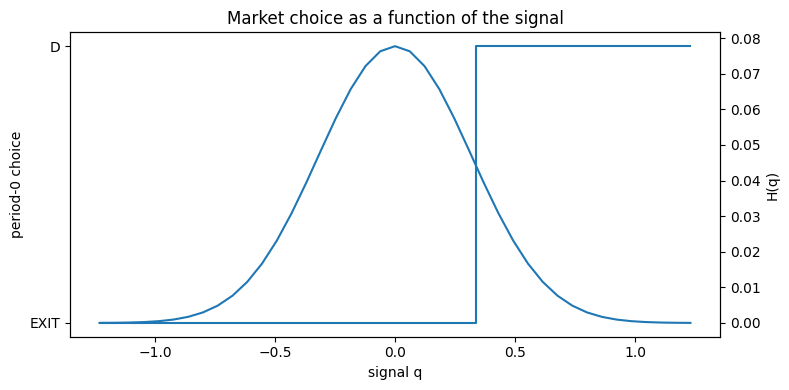

,q,H_q,choice_idx,choice,iH0,V0
0,-1.231174,0.000023,0,EXIT,0.000000,0.000000
1,-1.169615,0.000054,0,EXIT,0.000000,0.000000
2,-1.108057,0.000120,0,EXIT,0.000000,0.000000
3,-1.046498,0.000252,0,EXIT,0.000000,0.000000
4,-0.984939,0.000503,0,EXIT,0.000000,0.000000
5,-0.923381,0.000953,0,EXIT,0.000000,0.000000
6,-0.861822,0.001721,0,EXIT,0.000000,0.000000
7,-0.800263,0.002963,0,EXIT,0.000000,0.000000
8,-0.738704,0.004873,0,EXIT,0.000000,0.000000
9,-0.677146,0.007666,0,EXIT,0.000000,0.000000


In [ ]:
q_grid = signal_structure["q_grid"]
H_q = signal_structure["H_q"]
entry_choice = grid_sol_p0["entry_choice"]

entry_labels = [decode_mode(i, cfg) for i in entry_choice]

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.step(q_grid, entry_choice, where="mid")
ax1.set_yticks([pm_exit, pm_d])
ax1.set_yticklabels(["EXIT", "D"])
ax1.set_xlabel("signal q")
ax1.set_ylabel("period-0 choice")
ax1.set_title("Market choice as a function of the signal")

ax2 = ax1.twinx()
ax2.plot(q_grid, H_q)
ax2.set_ylabel("H(q)")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "q": q_grid,
    "H_q": H_q,
    "choice_idx": entry_choice,
    "choice": entry_labels,
    "iH0": grid_sol_p0["iH_star"],
    "V0": grid_sol_p0["V0"],
})

### Period 0

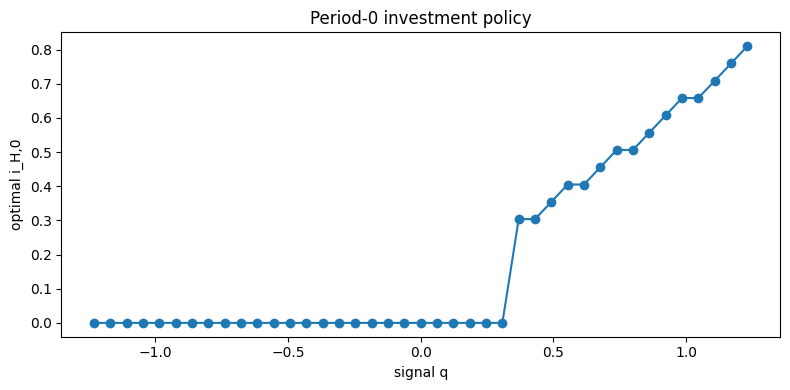

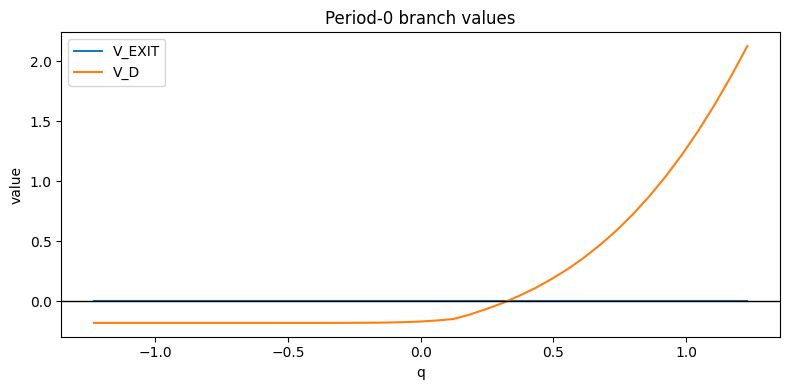

In [ ]:
# Period 0 Investment 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_grid, grid_sol_p0["iH_star"], marker="o")
ax.set_xlabel("signal q")
ax.set_ylabel("optimal i_H,0")
ax.set_title("Period-0 investment policy")
plt.tight_layout()
plt.show()

# Exit versus D period 0
p1_interps = build_period1_interpolators(KH_grid, KF_grid, s_grid, grid_sol_p1, cfg)

rows = []
for iq, q in enumerate(q_grid):
    sol = solve_period0_state(
        q_idx=iq,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
        KH0=0.0,
        KF0=0.0,
        include_outside_option=False,
    )
    rows.append({
        "q": q,
        "V_EXIT": sol["all"]["EXIT"]["value"],
        "V_D": sol["all"]["D"]["value"],
        "choice": sol["best_mode"],
        "iH_D": sol["all"]["D"]["i_H"],
        "EV1_D": sol["all"]["D"]["EV1"],
    })

q_table = pd.DataFrame(rows)
q_table.head()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_table["q"], q_table["V_EXIT"], label="V_EXIT")
ax.plot(q_table["q"], q_table["V_D"], label="V_D")
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("q")
ax.set_ylabel("value")
ax.set_title("Period-0 branch values")
ax.legend()
plt.tight_layout()
plt.show()


### Period 1 Investment Policy given that m_0 = D
small kinks in the investment curves come from numerical solving. The economic kink is because of the KKT conditions (i=0)

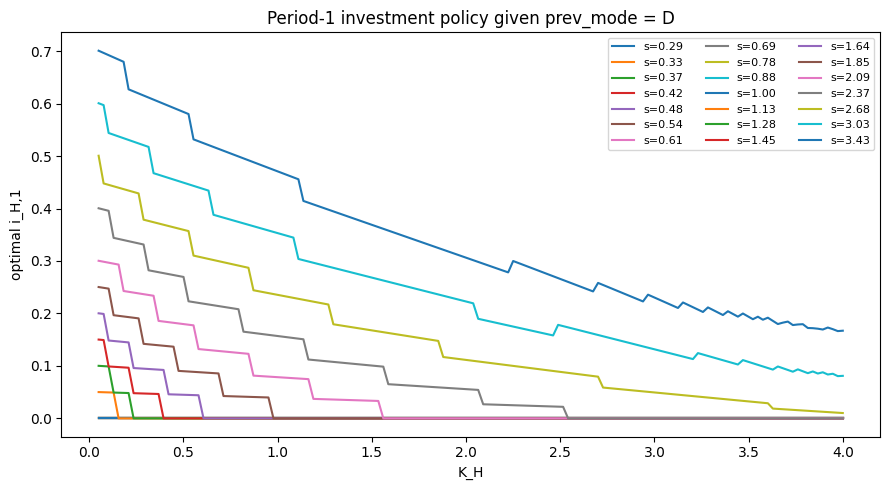

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for s_idx, s_val in enumerate(s_grid):
    ax.plot(
        KH_grid,
        grid_sol_p1["iH_star"][pm_d, :, kf_idx, s_idx],
        label=f"s={s_val:.2f}"
    )

ax.set_xlabel("K_H")
ax.set_ylabel("optimal i_H,1")
ax.set_title("Period-1 investment policy given prev_mode = D")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
policy_exit = grid_sol_p1["policy_mode"][pm_exit, :, kf_idx, :]
iH_exit = grid_sol_p1["iH_star"][pm_exit, :, kf_idx, :]

print("Unique period-1 choices when prev_mode = EXIT:",
      np.unique(policy_exit))

print("Max i_H when prev_mode = EXIT:",
      np.max(iH_exit))

Unique period-1 choices when prev_mode = EXIT: [0]
Max i_H when prev_mode = EXIT: 0.0


### Intesnive inaction region in period 1

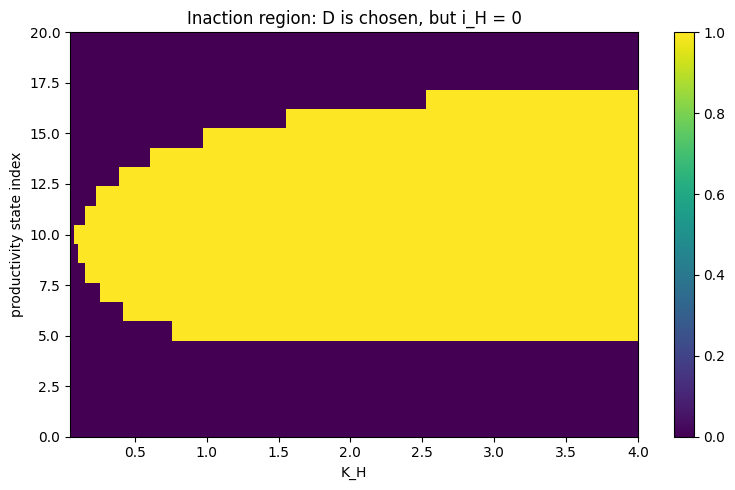

In [ ]:
policy_p1 = grid_sol_p1["policy_mode"][pm_d, :, kf_idx, :]
iH_p1 = grid_sol_p1["iH_star"][pm_d, :, kf_idx, :]

is_zero_invest = (
    (policy_p1 == pm_d) &
    np.isclose(iH_p1, 0.0, atol=1e-6)
).T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    is_zero_invest,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], 0, len(s_grid)-1]
)
ax.set_xlabel("K_H")
ax.set_ylabel("productivity state index")
ax.set_title("Inaction region: D is chosen, but i_H = 0")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Cutoffs

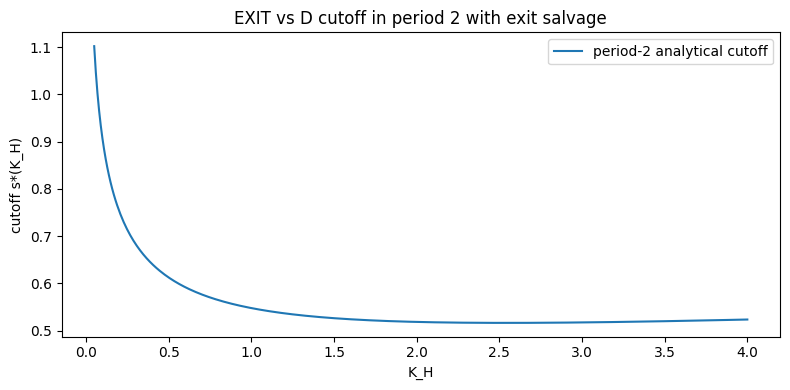

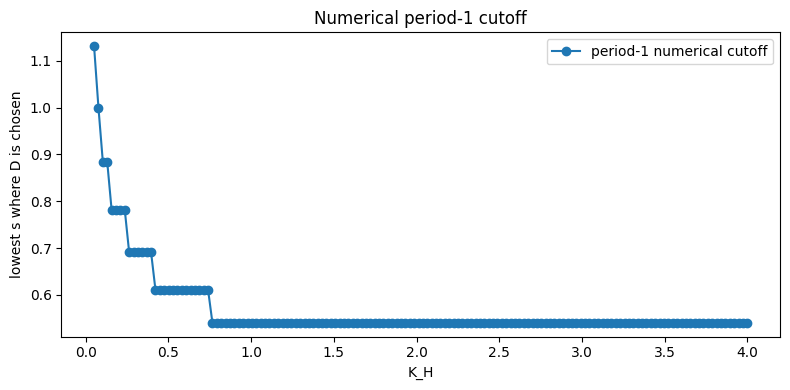

In [ ]:
# Period 2 
def s_cutoff_p2_with_exit_salvage(KH, p):
    numerator = p.f_H_op + p.xi_H * KH * (1.0 - p.beta * (1.0 - p.delta))
    denominator = p.Omega_H * KH**p.kappa
    return (numerator / denominator) ** (1.0 / p.rho)

KH_plot = np.linspace(0.05, 4.0, 400)
s_cut = s_cutoff_p2_with_exit_salvage(KH_plot, p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(KH_plot, s_cut, label="period-2 analytical cutoff")
ax.set_xlabel("K_H")
ax.set_ylabel("cutoff s*(K_H)")
ax.set_title("EXIT vs D cutoff in period 2 with exit salvage")
ax.legend()
plt.tight_layout()
plt.show()

# Period 1 
cutoff_s_idx_p1 = np.full(len(KH_grid), np.nan)

for i in range(len(KH_grid)):
    choices = grid_sol_p1["policy_mode"][pm_d, i, kf_idx, :]
    d_states = np.where(choices == pm_d)[0]
    if len(d_states) > 0:
        cutoff_s_idx_p1[i] = d_states[0]

cutoff_s_p1 = np.array([
    s_grid[int(idx)] if not np.isnan(idx) else np.nan
    for idx in cutoff_s_idx_p1
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(KH_grid, cutoff_s_p1, marker="o", linestyle="-", label="period-1 numerical cutoff")
ax.set_xlabel("K_H")
ax.set_ylabel("lowest s where D is chosen")
ax.set_title("Numerical period-1 cutoff")
ax.legend()
plt.tight_layout()
plt.show()

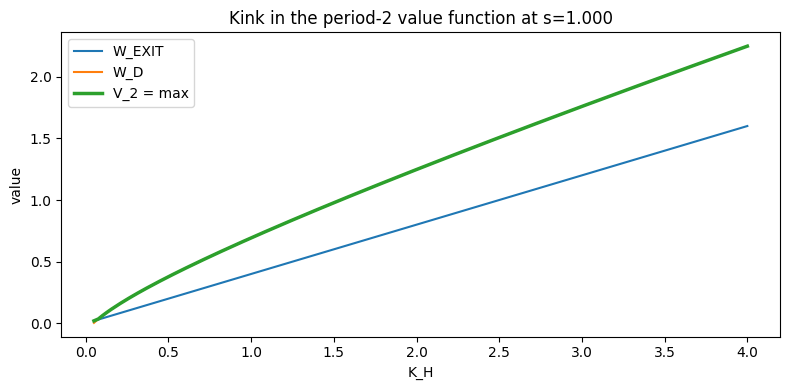

In [ ]:
s_fixed = s_grid[len(s_grid)//2]
prev_mode = "D"
KF_fixed = 0.0

W_exit = []
W_d = []
V = []

for KH in KH_grid:
    b_exit = branch_value_period2("EXIT", prev_mode, KH, KF_fixed, s_fixed, p, cfg)
    b_d = branch_value_period2("D", prev_mode, KH, KF_fixed, s_fixed, p, cfg)

    W_exit.append(b_exit["value"])
    W_d.append(b_d["value"])
    V.append(max(b_exit["value"], b_d["value"]))

W_exit = np.array(W_exit)
W_d = np.array(W_d)
V = np.array(V)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(KH_grid, W_exit, label="W_EXIT")
ax.plot(KH_grid, W_d, label="W_D")
ax.plot(KH_grid, V, linewidth=2.5, label="V_2 = max")
ax.set_xlabel("K_H")
ax.set_ylabel("value")
ax.set_title(f"Kink in the period-2 value function at s={s_fixed:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

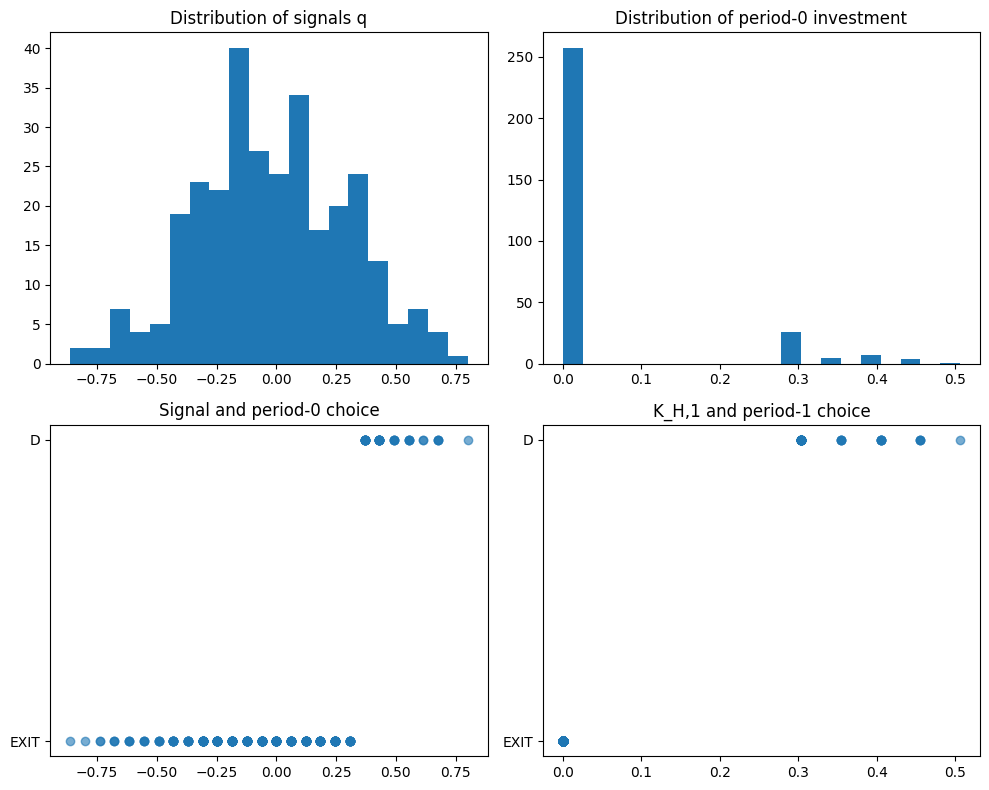

In [ ]:
rng = np.random.default_rng(123)
n_firms = 300

q_idx_draws = draw_signal_indices(signal_structure["H_q"], n_firms=n_firms, seed=123)
q_draws = signal_structure["q_grid"][q_idx_draws]

p1_interps = build_period1_interpolators(KH_grid, KF_grid, s_grid, grid_sol_p1, cfg)

rows = []

for firm_id, q_idx in enumerate(q_idx_draws):
    # ----- Period 0 -----
    sol0 = solve_period0_state(
        q_idx=int(q_idx),
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
        KH0=0.0,
        KF0=0.0,
        include_outside_option=False,
    )

    mode0 = sol0["best_mode"]
    iH0 = sol0["best"]["i_H"]
    KH1 = sol0["best"]["KH1"]

    # ----- Realize s1 from posterior -----
    posterior = signal_structure["posterior_q_to_s1"][q_idx, :]
    s1_idx = rng.choice(np.arange(len(s_grid)), p=posterior)
    s1 = s_grid[s1_idx]

    # ----- Period 1 -----
    sol1 = solve_period1_state(
        KH1=KH1,
        KF1=0.0,
        s1_idx=int(s1_idx),
        prev_mode=mode0,
        s_grid=s_grid,
        P=P,
        interps=grid_sol_p1["period2_interpolators"],
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )

    mode1 = sol1["best_mode"]
    iH1 = sol1["best"]["i_H"]
    KH2 = sol1["best"]["KH2"]

    # ----- Realize s2 -----
    s2_idx = rng.choice(np.arange(len(s_grid)), p=P[s1_idx, :])
    s2 = s_grid[s2_idx]

    # ----- Period 2 -----
    sol2 = solve_period2_state(
        KH=KH2,
        KF=0.0,
        s=s2,
        prev_mode=mode1,
        p=p,
        cfg=cfg,
    )

    mode2 = sol2["best_mode"]

    rows.append({
        "firm_id": firm_id,
        "q_idx": int(q_idx),
        "q": float(q_draws[firm_id]),
        "mode0": mode0,
        "iH0": float(iH0),
        "KH1": float(KH1),
        "s1_idx": int(s1_idx),
        "s1": float(s1),
        "mode1": mode1,
        "iH1": float(iH1),
        "KH2": float(KH2),
        "s2_idx": int(s2_idx),
        "s2": float(s2),
        "mode2": mode2,
    })

sim_df = pd.DataFrame(rows)
sim_df.head(15)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(sim_df["q"], bins=20)
axes[0, 0].set_title("Distribution of signals q")

axes[0, 1].hist(sim_df["iH0"], bins=20)
axes[0, 1].set_title("Distribution of period-0 investment")

sim_df["mode0_num"] = sim_df["mode0"].map({"EXIT": 0, "D": 1})
sim_df["mode1_num"] = sim_df["mode1"].map({"EXIT": 0, "D": 1})
sim_df["mode2_num"] = sim_df["mode2"].map({"EXIT": 0, "D": 1})

axes[1, 0].scatter(sim_df["q"], sim_df["mode0_num"], alpha=0.6)
axes[1, 0].set_title("Signal and period-0 choice")
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(["EXIT", "D"])

axes[1, 1].scatter(sim_df["KH1"], sim_df["mode1_num"], alpha=0.6)
axes[1, 1].set_title("K_H,1 and period-1 choice")
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_yticklabels(["EXIT", "D"])

plt.tight_layout()
plt.show()

# D versus X

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Benchmark: D vs X only
# ----------------------------
cfg = RegimeConfig(active_modes=("D", "X"))
p = ModelParams()

# Finer home-capital grid
KH_grid = np.linspace(0.05, 4.0, 150)

# Dummy foreign-capital grid (not used here)
KF_grid = np.array([0.0])

# Productivity process
z_grid, s_grid, P = rouwenhorst(n=21, rho=0.90, sigma_eps=0.12)

# Signal structure
signal_structure = build_signal_structure(
    z_grid=z_grid,
    P=P,
    signal_sd=0.15
)

# Solve backward
grid_sol_p2 = solve_period2_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
)

grid_sol_p1 = solve_period1_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    period2_sol=grid_sol_p2,
    p=p,
    cfg=cfg,
)

grid_sol_p0 = solve_period0_all_signals(
    signal_structure=signal_structure,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    period1_sol=grid_sol_p1,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
    KH0=0.0,
    KF0=0.0,
    include_outside_option=False,   # no EXIT in this benchmark
)

pm_d = cfg.mode_to_index["D"]
pm_x = cfg.mode_to_index["X"]
kf_idx = 0

def decode_mode(idx, cfg):
    return cfg.index_to_mode[int(idx)]

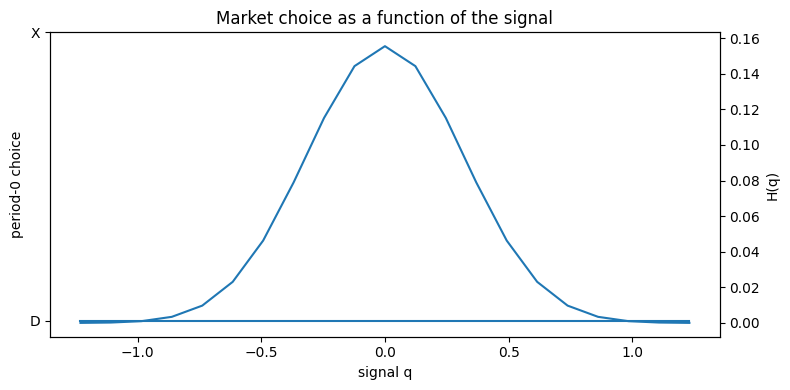

,q,H_q,choice_idx,choice,iH0,V0
0,-1.231174,0.000045,0,D,0.000000,-0.340927
1,-1.108057,0.000239,0,D,0.000000,-0.335569
2,-0.984939,0.001006,0,D,0.000000,-0.329078
3,-0.861822,0.003442,0,D,0.000000,-0.321268
4,-0.738704,0.009745,0,D,0.000000,-0.311912
5,-0.615587,0.023102,0,D,0.000000,-0.300737
6,-0.492470,0.046287,0,D,0.000000,-0.287420
7,-0.369352,0.078936,0,D,0.000000,-0.271558
8,-0.246235,0.115172,0,D,0.000000,-0.252539
9,-0.123117,0.144277,0,D,0.000000,-0.228990


In [ ]:
q_grid = signal_structure["q_grid"]
H_q = signal_structure["H_q"]
entry_choice = grid_sol_p0["entry_choice"]

entry_labels = [decode_mode(i, cfg) for i in entry_choice]

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.step(q_grid, entry_choice, where="mid")
ax1.set_yticks([pm_d, pm_x])
ax1.set_yticklabels(["D", "X"])
ax1.set_xlabel("signal q")
ax1.set_ylabel("period-0 choice")
ax1.set_title("Market choice as a function of the signal")

ax2 = ax1.twinx()
ax2.plot(q_grid, H_q)
ax2.set_ylabel("H(q)")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "q": q_grid,
    "H_q": H_q,
    "choice_idx": entry_choice,
    "choice": entry_labels,
    "iH0": grid_sol_p0["iH_star"],
    "V0": grid_sol_p0["V0"],
})

### Period 0 regime choice and investment

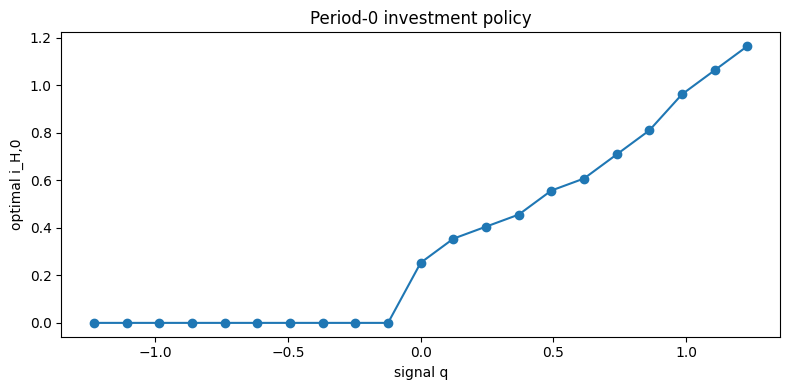

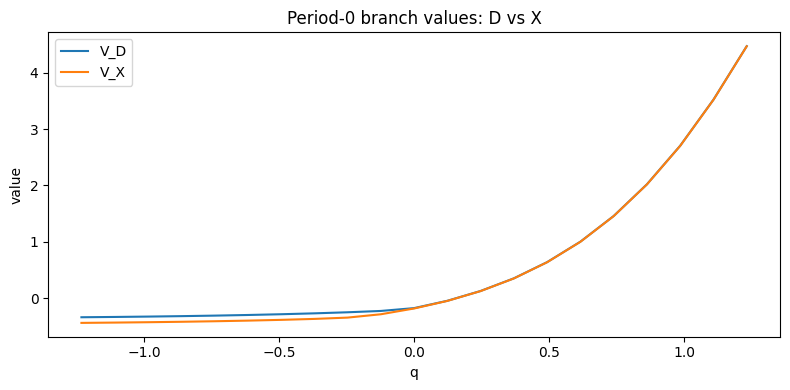

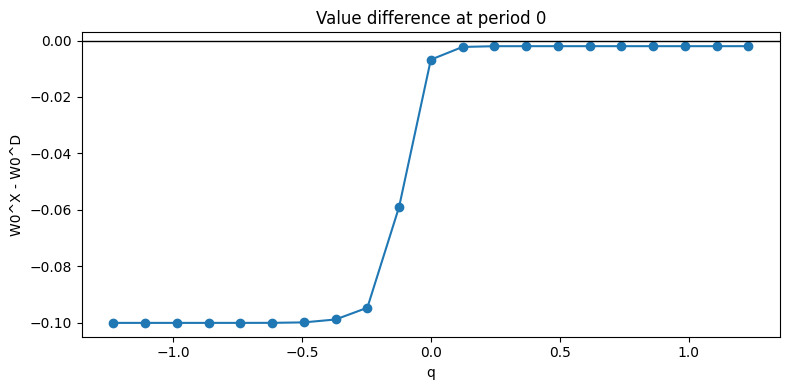

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_grid, grid_sol_p0["iH_star"], marker="o")
ax.set_xlabel("signal q")
ax.set_ylabel("optimal i_H,0")
ax.set_title("Period-0 investment policy")
plt.tight_layout()
plt.show()


p1_interps = build_period1_interpolators(KH_grid, KF_grid, s_grid, grid_sol_p1, cfg)

rows = []
for iq, q in enumerate(q_grid):
    b_d = solve_period0_branch_auto(
        mode="D",
        q_idx=iq,
        KH0=0.0,
        KF0=0.0,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )
    b_x = solve_period0_branch_auto(
        mode="X",
        q_idx=iq,
        KH0=0.0,
        KF0=0.0,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )

    rows.append({
        "q": q,
        "V_D": b_d["value"],
        "V_X": b_x["value"],
        "Delta0": b_x["value"] - b_d["value"],
        "iH0_D": b_d["i_H"],
        "iH0_X": b_x["i_H"],
        "choice": "X" if b_x["value"] > b_d["value"] else "D",
    })

q_table_dx = pd.DataFrame(rows)
q_table_dx.head()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_table_dx["q"], q_table_dx["V_D"], label="V_D")
ax.plot(q_table_dx["q"], q_table_dx["V_X"], label="V_X")
ax.set_xlabel("q")
ax.set_ylabel("value")
ax.set_title("Period-0 branch values: D vs X")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_table_dx["q"], q_table_dx["Delta0"], marker="o")
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("q")
ax.set_ylabel("W0^X - W0^D")
ax.set_title("Value difference at period 0")
plt.tight_layout()
plt.show()

### Period 1 investment 

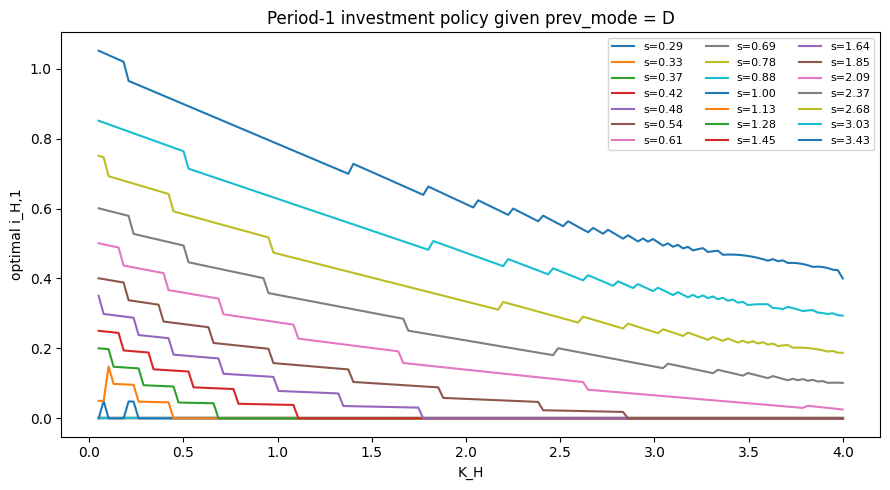

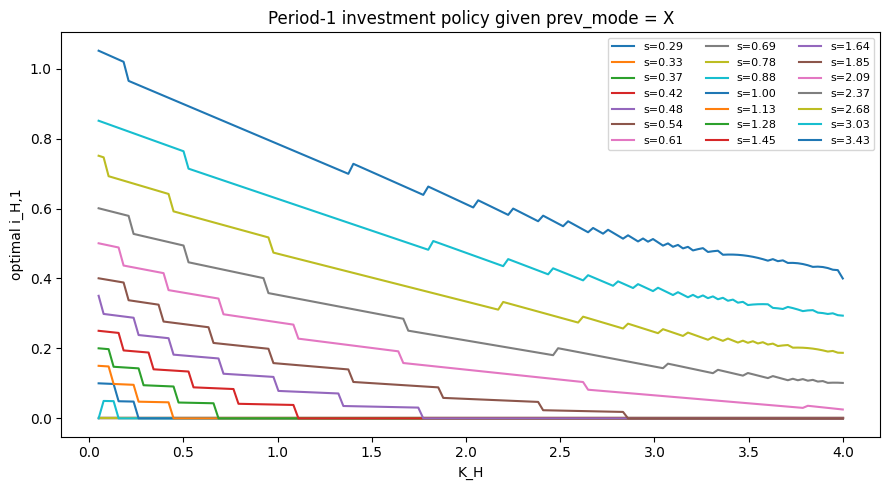

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for s_idx, s_val in enumerate(s_grid):
    ax.plot(
        KH_grid,
        grid_sol_p1["iH_star"][pm_d, :, kf_idx, s_idx],
        label=f"s={s_val:.2f}"
    )

ax.set_xlabel("K_H")
ax.set_ylabel("optimal i_H,1")
ax.set_title("Period-1 investment policy given prev_mode = D")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))

for s_idx, s_val in enumerate(s_grid):
    ax.plot(
        KH_grid,
        grid_sol_p1["iH_star"][pm_x, :, kf_idx, s_idx],
        label=f"s={s_val:.2f}"
    )

ax.set_xlabel("K_H")
ax.set_ylabel("optimal i_H,1")
ax.set_title("Period-1 investment policy given prev_mode = X")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

### History matters

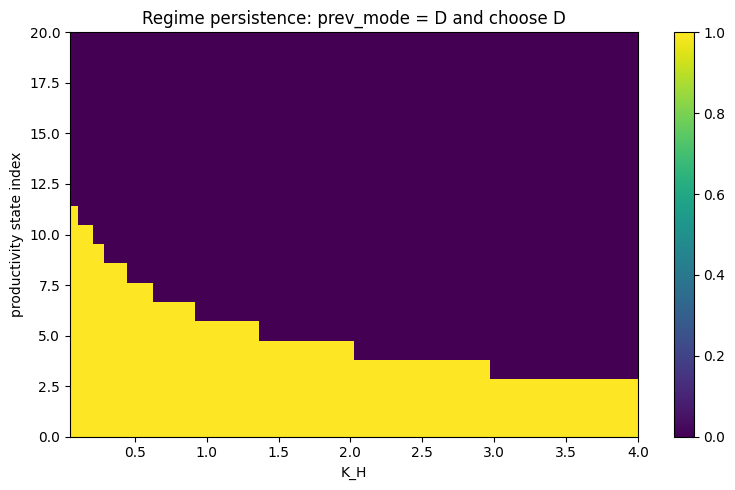

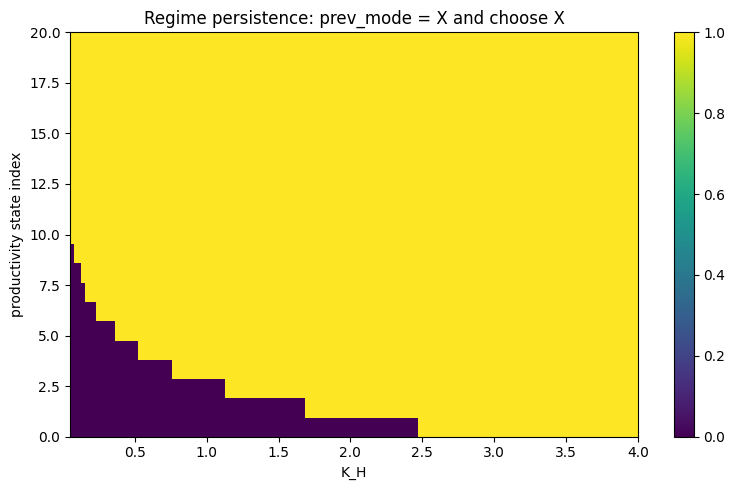

In [ ]:
policy_from_d = grid_sol_p1["policy_mode"][pm_d, :, kf_idx, :]
stay_d = (policy_from_d == pm_d).T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    stay_d,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], 0, len(s_grid)-1]
)
ax.set_xlabel("K_H")
ax.set_ylabel("productivity state index")
ax.set_title("Regime persistence: prev_mode = D and choose D")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

policy_from_x = grid_sol_p1["policy_mode"][pm_x, :, kf_idx, :]
stay_x = (policy_from_x == pm_x).T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    stay_x,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], 0, len(s_grid)-1]
)
ax.set_xlabel("K_H")
ax.set_ylabel("productivity state index")
ax.set_title("Regime persistence: prev_mode = X and choose X")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Hysteris region

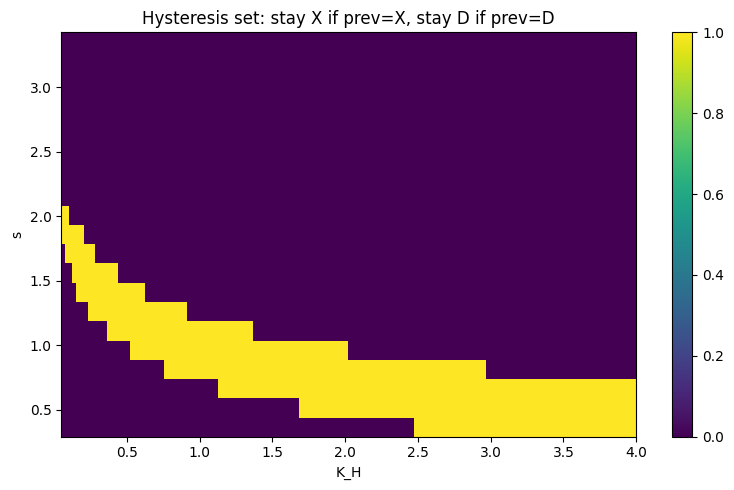

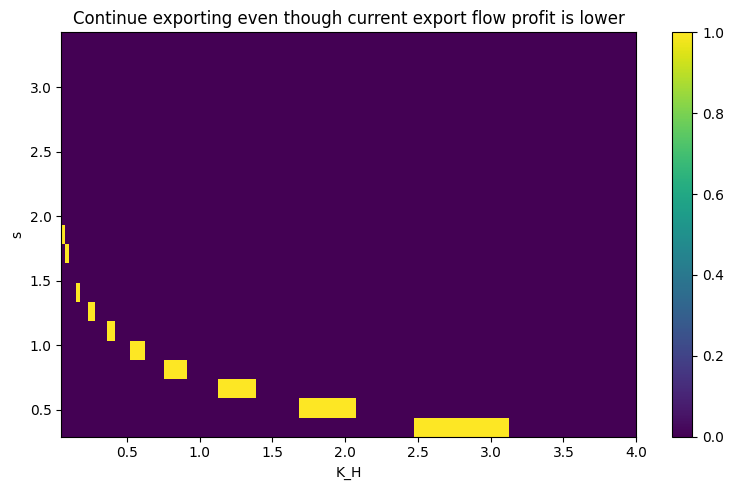

In [ ]:
def solve_period1_branch_auto(
    mode: str,
    prev_mode: str,
    KH1: float,
    KF1: float,
    s1_idx: int,
    s_grid: np.ndarray,
    P: np.ndarray,
    interps,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
):
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period1_branch_1d(
            mode=mode,
            prev_mode=prev_mode,
            KH1=KH1,
            s1_idx=s1_idx,
            s_grid=s_grid,
            P=P,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
        )
    else:
        return solve_period1_branch(
            mode=mode,
            prev_mode=prev_mode,
            KH1=KH1,
            KF1=KF1,
            s1_idx=s1_idx,
            s_grid=s_grid,
            P=P,
            interps=interps,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            p=p,
            cfg=cfg,
        )
    

p2_interps = grid_sol_p1["period2_interpolators"]

delta_prevD = np.empty((len(KH_grid), len(s_grid)))
delta_prevX = np.empty((len(KH_grid), len(s_grid)))

for i, KH in enumerate(KH_grid):
    for k in range(len(s_grid)):
        # Value difference when prev_mode = D
        bd_D = solve_period1_branch_auto(
            mode="D", prev_mode="D", KH1=KH, KF1=0.0, s1_idx=k,
            s_grid=s_grid, P=P, interps=p2_interps,
            KH_grid=KH_grid, KF_grid=KF_grid, p=p, cfg=cfg
        )
        bx_D = solve_period1_branch_auto(
            mode="X", prev_mode="D", KH1=KH, KF1=0.0, s1_idx=k,
            s_grid=s_grid, P=P, interps=p2_interps,
            KH_grid=KH_grid, KF_grid=KF_grid, p=p, cfg=cfg
        )
        delta_prevD[i, k] = bx_D["value"] - bd_D["value"]

        # Value difference when prev_mode = X
        bd_X = solve_period1_branch_auto(
            mode="D", prev_mode="X", KH1=KH, KF1=0.0, s1_idx=k,
            s_grid=s_grid, P=P, interps=p2_interps,
            KH_grid=KH_grid, KF_grid=KF_grid, p=p, cfg=cfg
        )
        bx_X = solve_period1_branch_auto(
            mode="X", prev_mode="X", KH1=KH, KF1=0.0, s1_idx=k,
            s_grid=s_grid, P=P, interps=p2_interps,
            KH_grid=KH_grid, KF_grid=KF_grid, p=p, cfg=cfg
        )
        delta_prevX[i, k] = bx_X["value"] - bd_X["value"]

hysteresis_set = ((delta_prevD < 0) & (delta_prevX > 0)).T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    hysteresis_set,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], s_grid[0], s_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("s")
ax.set_title("Hysteresis set: stay X if prev=X, stay D if prev=D")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

flow_gap = np.empty((len(KH_grid), len(s_grid)))

for i, KH in enumerate(KH_grid):
    for k, s in enumerate(s_grid):
        flow_gap[i, k] = flow_profit("X", KH, 0.0, s, p) - flow_profit("D", KH, 0.0, s, p)

continue_export_despite_flow_loss = ((flow_gap < 0) & (delta_prevX > 0)).T

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    continue_export_despite_flow_loss,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], s_grid[0], s_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("s")
ax.set_title("Continue exporting even though current export flow profit is lower")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



# Comparison of D,X, HF

In [126]:
def solve_period0_branch_auto(
    mode: str,
    q_idx: int,
    KH0: float,
    KF0: float,
    signal_structure,
    interps,
    KH_grid,
    KF_grid,
    p,
    cfg,
):
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period0_branch_1d(
            mode=mode,
            q_idx=q_idx,
            KH0=KH0,
            signal_structure=signal_structure,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
        )
    return solve_period0_branch(
        mode=mode,
        q_idx=q_idx,
        KH0=KH0,
        KF0=KF0,
        signal_structure=signal_structure,
        interps=interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )

def solve_period1_branch_auto(
        
    mode: str,
    prev_mode: str,
    KH1: float,
    KF1: float,
    s1_idx: int,
    s_grid,
    P,
    interps,
    KH_grid,
    KF_grid,
    p,
    cfg,
):
    if use_kh_only_solver(cfg, KF_grid):
        return solve_period1_branch_1d(
            mode=mode,
            prev_mode=prev_mode,
            KH1=KH1,
            s1_idx=s1_idx,
            s_grid=s_grid,
            P=P,
            cache=interps,
            KH_grid=KH_grid,
            p=p,
            cfg=cfg,
        )
    return solve_period1_branch(
        mode=mode,
        prev_mode=prev_mode,
        KH1=KH1,
        KF1=KF1,
        s1_idx=s1_idx,
        s_grid=s_grid,
        P=P,
        interps=interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )


cfg = RegimeConfig(active_modes=("D", "X", "HF"))
p = ModelParams()

# Start with modest grids: full 2D problem is much slower than D-vs-X
KH_grid = np.linspace(0.10, 4.0, 15)
KF_grid = np.linspace(0.00, 2.5, 10)

z_grid, s_grid, P = rouwenhorst(n=7, rho=0.90, sigma_eps=0.12)

signal_structure = build_signal_structure(
    z_grid=z_grid,
    P=P,
    signal_sd=0.15
)

grid_sol_p2 = solve_period2_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
)

grid_sol_p1 = solve_period1_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    period2_sol=grid_sol_p2,
    p=p,
    cfg=cfg,
)

grid_sol_p0 = solve_period0_all_signals(
    signal_structure=signal_structure,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    period1_sol=grid_sol_p1,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
    KH0=0.0,
    KF0=0.0,
    include_outside_option=False,
)

pm_d = cfg.mode_to_index["D"]
pm_x = cfg.mode_to_index["X"]
pm_hf = cfg.mode_to_index["HF"]

def decode_mode(idx, cfg):
    return cfg.index_to_mode[int(idx)]

### Period 0 market choice, Investment and branch values

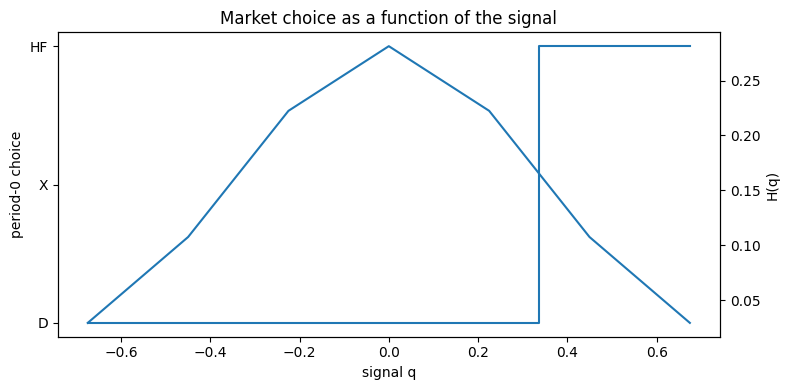

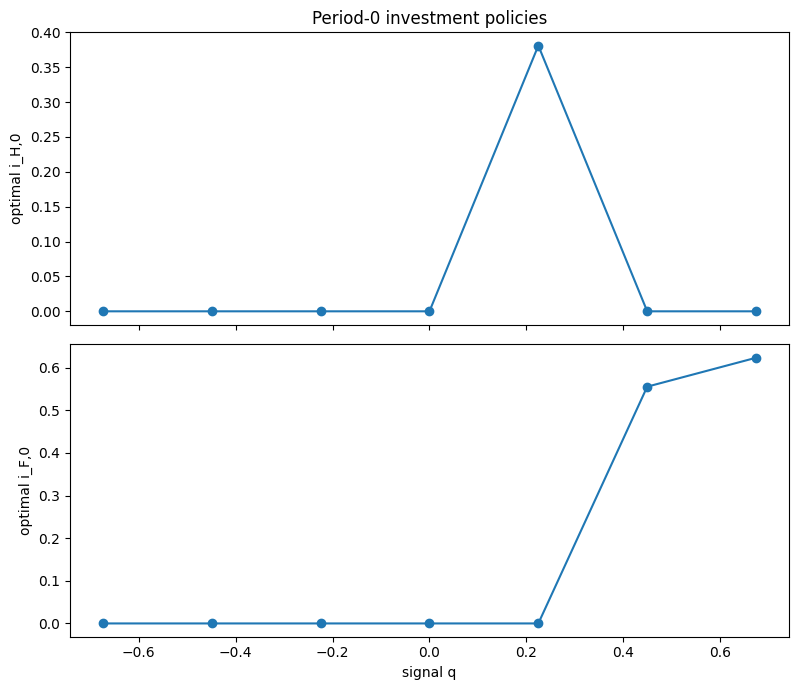

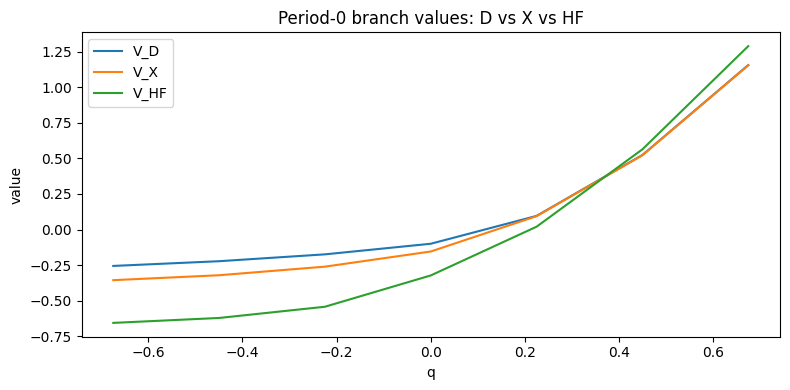

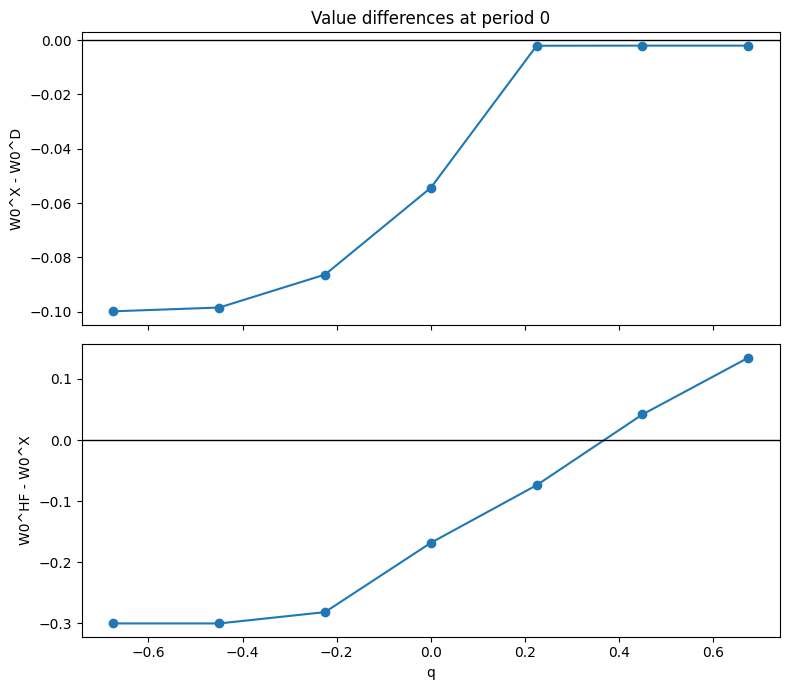

In [127]:
q_grid = signal_structure["q_grid"]
H_q = signal_structure["H_q"]
entry_choice = grid_sol_p0["entry_choice"]

entry_labels = [decode_mode(i, cfg) for i in entry_choice]

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.step(q_grid, entry_choice, where="mid")
ax1.set_yticks([pm_d, pm_x, pm_hf])
ax1.set_yticklabels(["D", "X", "HF"])
ax1.set_xlabel("signal q")
ax1.set_ylabel("period-0 choice")
ax1.set_title("Market choice as a function of the signal")

ax2 = ax1.twinx()
ax2.plot(q_grid, H_q)
ax2.set_ylabel("H(q)")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "q": q_grid,
    "H_q": H_q,
    "choice_idx": entry_choice,
    "choice": entry_labels,
    "iH0": grid_sol_p0["iH_star"],
    "iF0": grid_sol_p0["iF_star"],
    "V0": grid_sol_p0["V0"],
})

# --- Period 0 investment policies
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(q_grid, grid_sol_p0["iH_star"], marker="o")
axes[0].set_ylabel("optimal i_H,0")
axes[0].set_title("Period-0 investment policies")

axes[1].plot(q_grid, grid_sol_p0["iF_star"], marker="o")
axes[1].set_xlabel("signal q")
axes[1].set_ylabel("optimal i_F,0")

plt.tight_layout()
plt.show()

# --- Period 0 branch values
p1_interps = build_period1_interpolators(KH_grid, KF_grid, s_grid, grid_sol_p1, cfg)

rows = []
for iq, q in enumerate(q_grid):
    b_d = solve_period0_branch_auto(
        mode="D",
        q_idx=iq,
        KH0=0.0,
        KF0=0.0,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )
    b_x = solve_period0_branch_auto(
        mode="X",
        q_idx=iq,
        KH0=0.0,
        KF0=0.0,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )
    b_hf = solve_period0_branch_auto(
        mode="HF",
        q_idx=iq,
        KH0=0.0,
        KF0=0.0,
        signal_structure=signal_structure,
        interps=p1_interps,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        p=p,
        cfg=cfg,
    )

    rows.append({
        "q": q,
        "V_D": b_d["value"],
        "V_X": b_x["value"],
        "V_HF": b_hf["value"],
        "Delta_X_D": b_x["value"] - b_d["value"],
        "Delta_HF_X": b_hf["value"] - b_x["value"],
        "iH0_D": b_d["i_H"],
        "iH0_X": b_x["i_H"],
        "iH0_HF": b_hf["i_H"],
        "iF0_HF": b_hf["i_F"],
    })

q_table_dxhf = pd.DataFrame(rows)
q_table_dxhf.head()



fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_table_dxhf["q"], q_table_dxhf["V_D"], label="V_D")
ax.plot(q_table_dxhf["q"], q_table_dxhf["V_X"], label="V_X")
ax.plot(q_table_dxhf["q"], q_table_dxhf["V_HF"], label="V_HF")
ax.set_xlabel("q")
ax.set_ylabel("value")
ax.set_title("Period-0 branch values: D vs X vs HF")
ax.legend()
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(q_table_dxhf["q"], q_table_dxhf["Delta_X_D"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_ylabel("W0^X - W0^D")
axes[0].set_title("Value differences at period 0")

axes[1].plot(q_table_dxhf["q"], q_table_dxhf["Delta_HF_X"], marker="o")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_xlabel("q")
axes[1].set_ylabel("W0^HF - W0^X")

plt.tight_layout()
plt.show()

Using s1 = 1.0


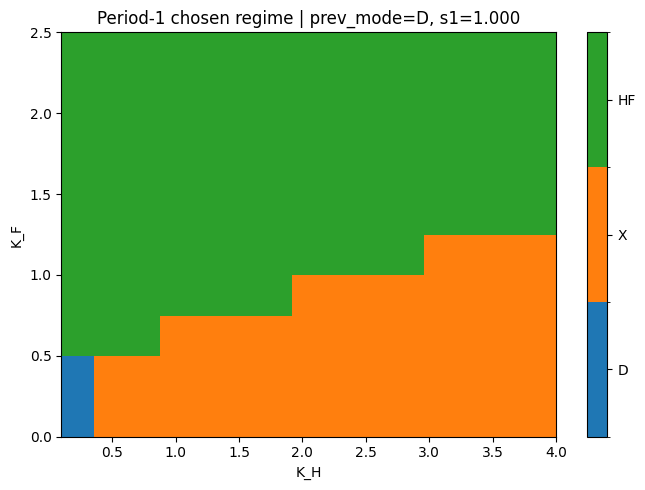

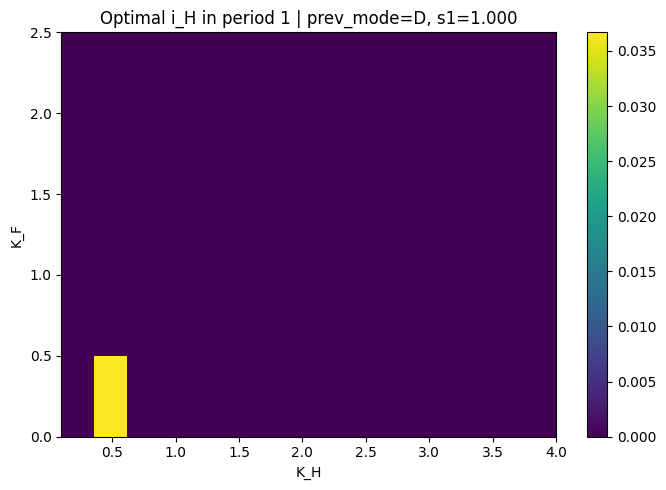

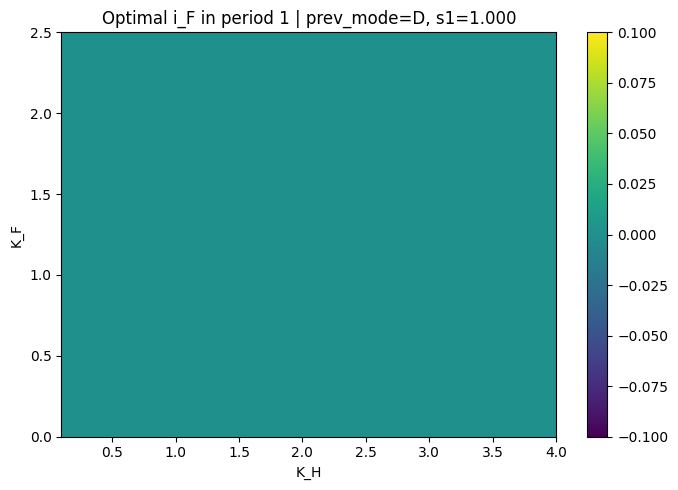

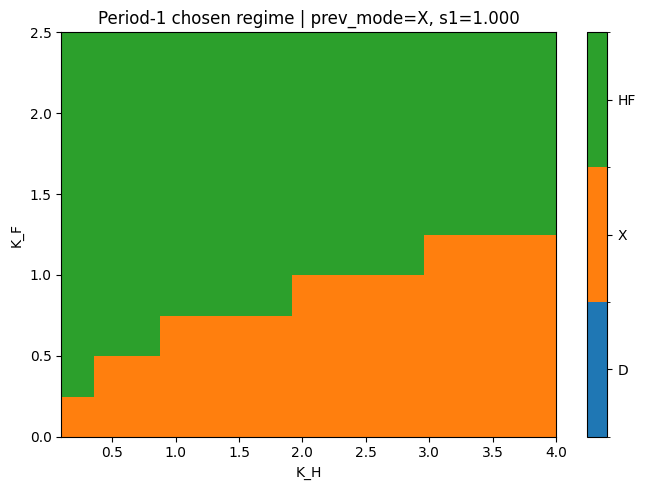

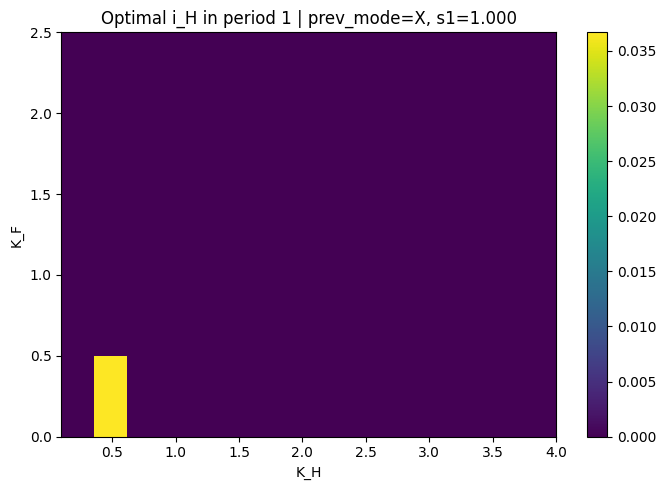

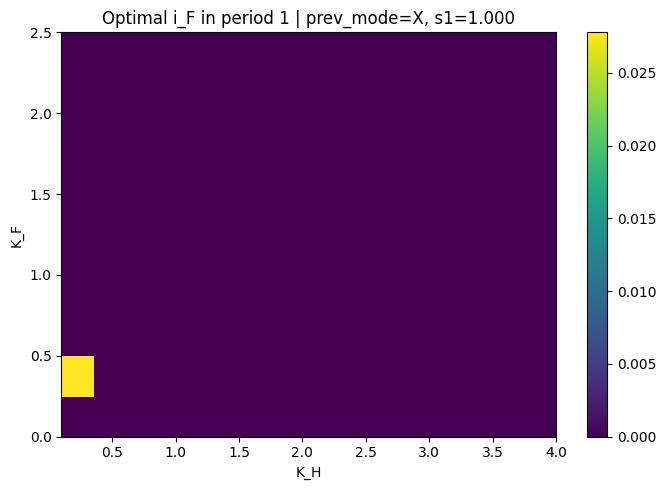

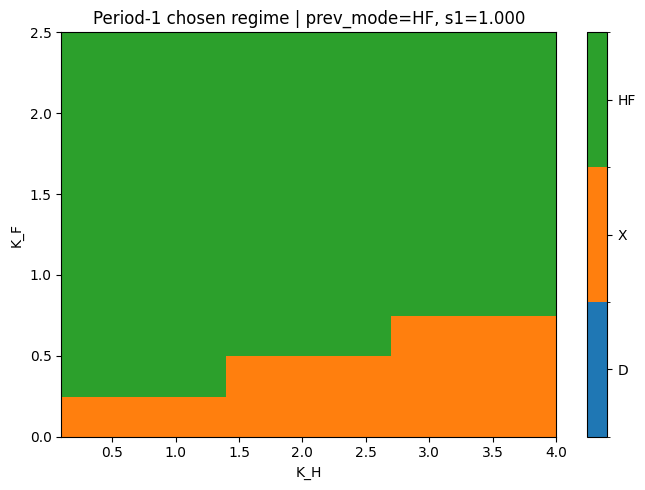

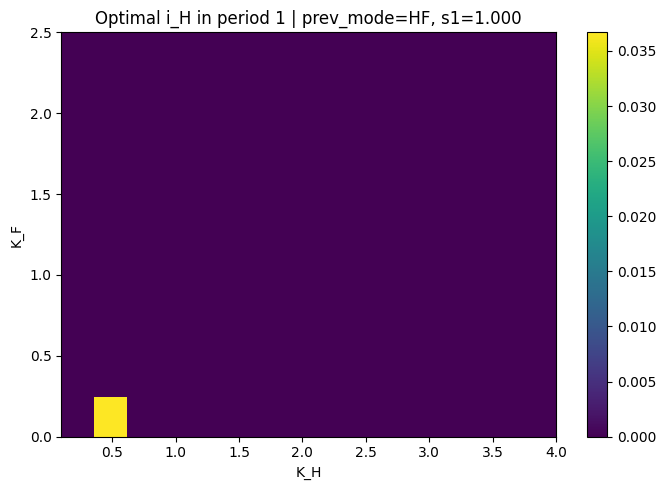

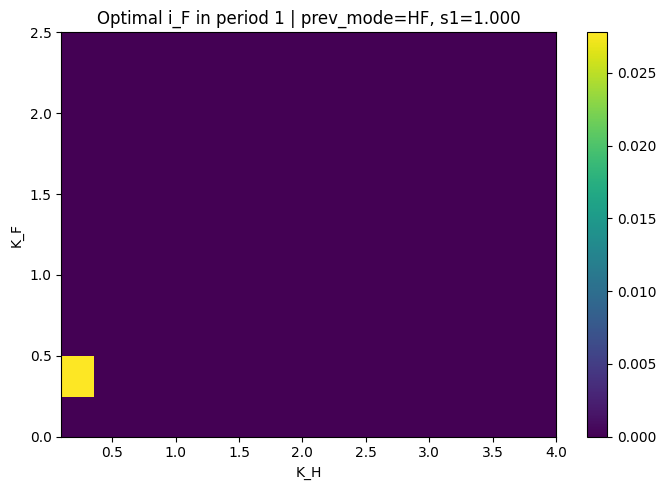

In [128]:
s_idx_mid = len(s_grid) // 2
s_val_mid = s_grid[s_idx_mid]
print("Using s1 =", s_val_mid)

plot_period1_policy_slices(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    policy_mode=grid_sol_p1["policy_mode"],
    iH_star=grid_sol_p1["iH_star"],
    iF_star=grid_sol_p1["iF_star"],
    fixed_prev_mode="D",
    fixed_s_idx=s_idx_mid,
    cfg=cfg,
    save_prefix=None,
)

plot_period1_policy_slices(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    policy_mode=grid_sol_p1["policy_mode"],
    iH_star=grid_sol_p1["iH_star"],
    iF_star=grid_sol_p1["iF_star"],
    fixed_prev_mode="X",
    fixed_s_idx=s_idx_mid,
    cfg=cfg,
    save_prefix=None,
)

plot_period1_policy_slices(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    policy_mode=grid_sol_p1["policy_mode"],
    iH_star=grid_sol_p1["iH_star"],
    iF_star=grid_sol_p1["iF_star"],
    fixed_prev_mode="HF",
    fixed_s_idx=s_idx_mid,
    cfg=cfg,
    save_prefix=None,
)

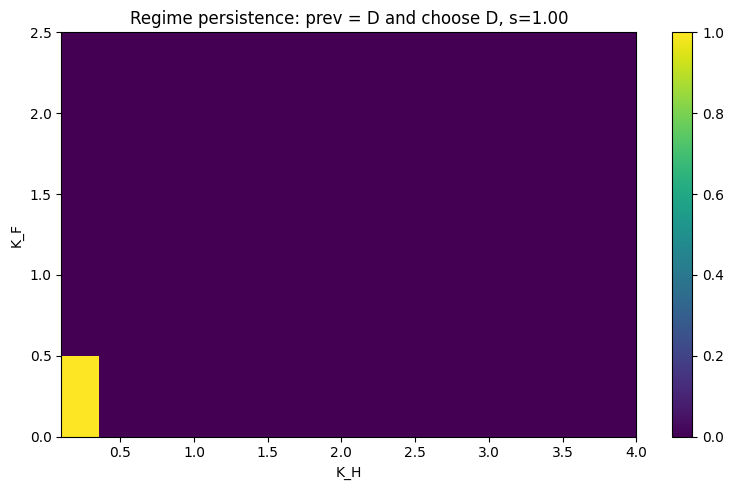

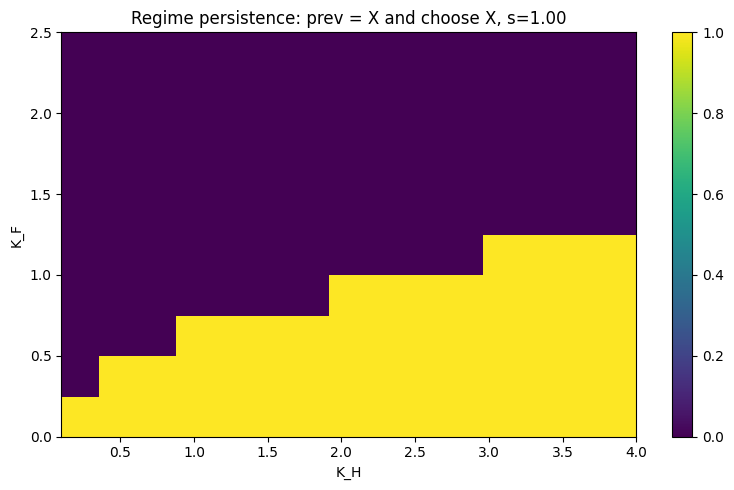

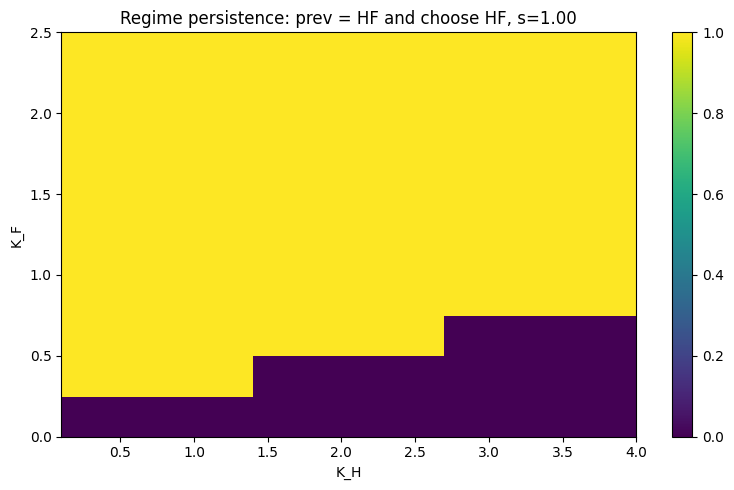

In [129]:
policy_from_d = grid_sol_p1["policy_mode"][pm_d, :, :, s_idx_mid]
policy_from_x = grid_sol_p1["policy_mode"][pm_x, :, :, s_idx_mid]
policy_from_hf = grid_sol_p1["policy_mode"][pm_hf, :, :, s_idx_mid]

stay_d = (policy_from_d == pm_d).T
stay_x = (policy_from_x == pm_x).T
stay_hf = (policy_from_hf == pm_hf).T

# --- Stay domestic if previously domestic
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    stay_d,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("K_F")
ax.set_title(f"Regime persistence: prev = D and choose D, s={s_val_mid:.2f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# --- Stay exporter if previously exporter
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    stay_x,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("K_F")
ax.set_title(f"Regime persistence: prev = X and choose X, s={s_val_mid:.2f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# --- Stay multinational if previously HF
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    stay_hf,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("K_F")
ax.set_title(f"Regime persistence: prev = HF and choose HF, s={s_val_mid:.2f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Hysteris regions

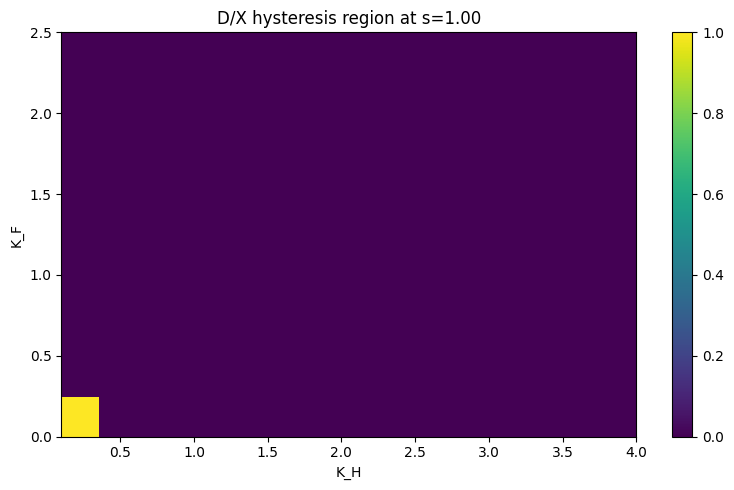

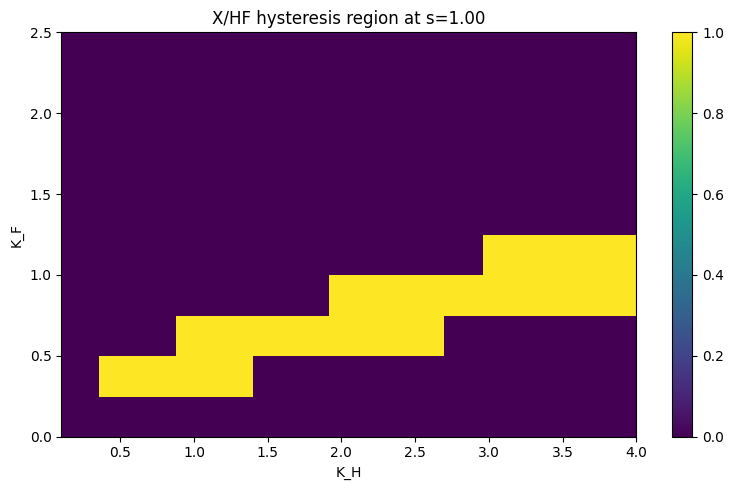

In [130]:
dx_hysteresis = (stay_d & stay_x)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    dx_hysteresis,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("K_F")
ax.set_title(f"D/X hysteresis region at s={s_val_mid:.2f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

xhf_hysteresis = (stay_x & stay_hf)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    xhf_hysteresis,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
ax.set_xlabel("K_H")
ax.set_ylabel("K_F")
ax.set_title(f"X/HF hysteresis region at s={s_val_mid:.2f}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()